# A Quantum Approach to Stochastic Optimization in Insurance Underwriting

Reproduction of **Bordelon, Garfinkel, Dixit, Whitehead, Holzbauer, Mijares Vilarino,
Maldonado Romo, Mitra, Kumar & Utke**, *"A Quantum Approach to Stochastic Optimization in
Insurance Underwriting"* (Allstate / IBM Quantum, June 2026, arXiv:2605.01169).

Three instances, one theory block, then straight into mapping, training and execution.

| $n$ | $M$ | $p$ | Where it runs | What you get |
|---|---|---|---|---|
| 20  | 5 | 9 | MPS simulator, locally | Brute-force ground truth, so the simulated $\kappa$ can be *checked*. Reproduces Table 2 row 1. |
| 100 | 5 | 7 | **Real hardware**, gated | Transfer from a 50-item surrogate, SWAP-free layout, `Session` loop. Nothing at this width is simulated. |
| 150 | 5 | 7 | **DIY on hardware** | Same code, same surrogate. The mapping is qualitatively harder and the DIY blocks say why. |

**Reproduced exactly:** Table 2's circuit resources (all 21 numbers, all 7 rows) and
$\kappa=100.0\%$ at $n=20$. Every $\kappa$ is normalized to a *proven optimum* — §10 gets one out of
`qiskit-addon-opt-mapper` with no commercial solver, which is what makes these numbers comparable to
Table 2's. **Not reproduced:** Fig. 2, Table 1's Gurobi timings, and Figs. 3–8 (hundreds of circuit
evaluations at $n\ge20$ — QPU work, not simulator work).


In [ ]:
# Uncomment on a fresh machine / first run of the workshop:
# %pip install -q qiskit qiskit-aer qiskit-ibm-runtime
# %pip install -q "git+https://github.com/qiskit-community/qopt-best-practices.git"
# %pip install -q "git+https://github.com/qiskit-community/qaoa_training_pipeline.git"
# %pip install -q quimb   # transitive dependency pulled in by qaoa_training_pipeline
# %pip install -q qiskit-addon-opt-mapper   # exact classical reference (Section 10)

import time
import random
import itertools
from dataclasses import dataclass, field

import numpy as np
import matplotlib.pyplot as plt
import rustworkx as rx
from scipy.stats import norm
from scipy.optimize import minimize, linear_sum_assignment

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

NSHOTS = 2 ** 15         # the paper's N_shots (Sect. 2.4)
P_TRANSFER_PREVIEW = 7   # Table 2's p for n >= 50; used for the MPS cost preview in Section 4

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
print("Environment ready.")


## 1. The one bit of theory you cannot skip

For item $i$ and constraint $m$, the weight $\tilde w_i^{(m)}$ is **random**, with mean
$\mu_i^{(m)}$ and standard deviation $\sigma_i^{(m)}$. Each capacity only has to hold with high
probability:

$$
\max_{x\in\{0,1\}^n}\ \sum_i v_i x_i \quad\text{s.t.}\quad
\mathbb{P}\Big(\sum_i \tilde w_i^{(m)}x_i\le C^{(m)}\Big)\ge 1-\epsilon,\ \ \forall m. \tag{1}
$$

In underwriting terms: $v_i$ is the return on writing policy $i$, $\tilde w^{(m)}$ are risk
exposures that a predictive model estimates *as distributions*, $C^{(m)}$ are capital limits, and
$\epsilon$ is the appetite for breaching one.

**Theorem 1** removes the probability. Since $x_i^2=x_i$, the total weight
$B^{(m)}=\sum_i\tilde w_i^{(m)}x_i$ has mean $\sum_i\mu_i^{(m)}x_i$ and variance
$\sum_i(\sigma_i^{(m)})^2x_i$; if the weight distribution is **closed under convolution** with a
strictly increasing CDF $\Phi$ (Normal, Cauchy, Lévy — the paper uses Normal), then $B^{(m)}$ stays
in the same family, standardizing gives an $x$-independent distribution, and the chance constraint
becomes an exact algebraic one:

$$
\boxed{\ \sum_i \mu_i^{(m)}x_i\ +\ \underbrace{\Phi^{-1}(1-\epsilon)}_{z_\epsilon}\sqrt{\sum_i(\sigma_i^{(m)})^2x_i}\ \le\ C^{(m)}\ }\qquad\forall m \tag{3}
$$

**Everything unusual about this paper follows from one feature of Eq. 3: the risk term
$\sqrt{\sum_i(\sigma_i^{(m)})^2x_i}$ is not separable across items.** A QUBO/Ising cost operator is
a sum of one- and two-body terms; a square root of a sum is neither. So the risk half of the
constraint *cannot be written into a diagonal phase operator at all*. Consequently:

* the **circuit** encodes only $v_i$ and $\mu_i^{(m)}$ — never $\sigma$ (§3);
* the **risk enters only through the classical loss**, which is why this is a Sampler pipeline
  scored on individual bitstrings rather than an Estimator pipeline (§7);
* the **repair heuristic** must re-check all $M$ constraints after every single bit flip, because
  there is no fixed per-item weight to compare against remaining slack (§5).

Two smaller points, then we build. The paper's loss is
$f(x)=-v^\top x+\lambda\sum_m\max(0,L_m(x)-C^{(m)})$ with $\lambda=\sum_i v_i$ — chosen so one unit
of violation always costs more than the entire attainable profit, which makes the *sign* of the loss
a feasibility test. And what is minimized is not the mean of $f$ but the **lower-tail CVaR$(\xi)$**,
the mean of the best $\xi$ fraction of shots, because the deliverable is one excellent bitstring out
of $2^{15}$, not a good average.


## 2. Problem representation and the loss

One dataclass, everything vectorized over a batch of bitstrings — at $N_{shots}=2^{15}$ we hold
$\sim\!3\times10^4$ unique samples and a Python loop inside a COBYLA objective would dominate the
runtime. `losses()` implements Eq. 23/26 for all samples at once.

> Eq. 23 as typeset puts one `max` around the whole sum over $m$, which would let slack in one
> constraint cancel a violation in another. Eq. 26 and App. D Eq. 43 both write the per-constraint
> sum instead, and that is the only version under which $f(x)<0$ certifies feasibility. We use it.


In [3]:
@dataclass
class CCKPInstance:
    n: int
    M: int
    v: np.ndarray        # (n,)      item values
    mu: np.ndarray       # (M, n)    mean weights
    sigma: np.ndarray    # (M, n)    weight std devs
    C: np.ndarray        # (M,)      capacities
    z: float             # z_eps = Phi^{-1}(1 - eps)
    sig2: np.ndarray = field(init=False, repr=False)
    lam: float = field(init=False, repr=False)

    def __post_init__(self):
        self.sig2 = self.sigma ** 2
        self.lam = float(self.v.sum())      # Eq. 23: lambda = sum_i v_i

    # ---- batched primitives: X has shape (K, n) ------------------------------
    def lhs(self, X):
        '''L_m(x) for every sample and constraint -> (K, M).  Eq. (24).'''
        X = np.atleast_2d(X)
        return X @ self.mu.T + self.z * np.sqrt(np.maximum(X @ self.sig2.T, 0.0))

    def residual(self, X):
        '''r^(m)(x) = L_m(x) - C^(m) -> (K, M).  Eq. (25).'''
        return self.lhs(X) - self.C[None, :]

    def violation(self, X):
        '''sum_m max(0, r^(m)(x)) -> (K,).  The penalty term of Eq. (23)/(26).'''
        return np.maximum(0.0, self.residual(X)).sum(axis=1)

    def feasible(self, X):
        return np.all(self.residual(X) <= 1e-9, axis=1)

    def profits(self, X):
        return np.atleast_2d(X) @ self.v

    def losses(self, X):
        '''Eq. 23/26 -> (loss, is_feasible, profit), each of shape (K,).'''
        viol = self.violation(X)
        prof = self.profits(X)
        return -prof + self.lam * viol, viol <= 0.0, prof

    # ---- scalar conveniences -------------------------------------------------
    def is_feasible(self, x):  return bool(self.feasible(x)[0])
    def profit(self, x):       return float(self.profits(x)[0])
    def loss(self, x):
        l, f, p = self.losses(x)
        return float(l[0]), bool(f[0]), float(p[0])


def make_paper_instance(n, M, seed, vmax=50, mu_max=5, rC=0.25, rD=0.5, eps=0.2):
    '''Sect. 2.2, phase 3: sigma^2 = 1 fixed, capacity as rC * total mean weight
    (the reading established in Section 1), rD-density mask applied to mu AND sigma.'''
    rng = np.random.default_rng(seed)
    v     = rng.uniform(0.01, vmax, n).round(2)              # v_i ~ U(0, vmax]
    mu    = rng.uniform(0.01, mu_max, (M, n)).round(2)       # mu_i^(m) ~ U(0, mu_max]
    sigma = np.ones((M, n))                                  # sigma^2 = 1
    mask  = rng.random((M, n)) < rD                          # density ratio rD
    mu, sigma = mu * mask, sigma * mask
    C = (rC * mu.sum(axis=1)).round(2)
    return CCKPInstance(n=n, M=M, v=v, mu=mu, sigma=sigma, C=C, z=float(norm.ppf(1 - eps)))


def counts_to_arrays(counts):
    '''Qiskit counts dict -> (X, w) with X of shape (K, n) and X[:, i] = x_i.
    Vectorized string parsing: at 2^15 shots a Python loop here is the bottleneck.'''
    keys = list(counts.keys())
    w = np.fromiter((counts[k] for k in keys), dtype=np.int64, count=len(keys))
    raw = np.frombuffer("".join(keys).encode(), dtype=np.uint8).reshape(len(keys), -1)
    X = (raw[:, ::-1] - ord("0")).astype(np.int8)   # Qiskit prints q_{n-1}...q_0
    return X, w

print("CCKPInstance ready.")


CCKPInstance ready.


In [4]:
def counts_to_cvar(instance, counts, xi=0.2):
    '''Lower-tail CVaR(xi) of the Eq. 23 loss over the shot-weighted empirical distribution.
    Exact at the tail boundary: the boundary bitstring is partially weighted.'''
    X, w = counts_to_arrays(counts)
    loss, _, _ = instance.losses(X)
    order = np.argsort(loss)
    l, ww = loss[order], w[order]
    cum = np.cumsum(ww)
    k = max(1, int(np.ceil(xi * cum[-1])))          # how many shots the tail holds
    j = int(np.searchsorted(cum, k))
    take = ww[:j + 1].astype(float).copy()
    take[-1] -= cum[j] - k                          # partial weight on the boundary sample
    return float((l[:j + 1] * take).sum() / take.sum())


def sample_counts(sim, qc, param_order, theta, shots=NSHOTS, seed=None):
    bound = qc.assign_parameters(dict(zip(param_order, theta)))
    return sim.run(bound, shots=shots, seed_simulator=seed).result().get_counts()


def cvar_objective(sim, instance, qc, param_order, theta, shots=NSHOTS, xi=0.2, seed=1):
    return counts_to_cvar(instance, sample_counts(sim, qc, param_order, theta, shots, seed), xi)


def train(sim, instance, qc, param_order, theta0, maxiter, shots=NSHOTS, xi=0.2, seed=1,
          trace=None, label=""):
    '''COBYLA on the CVaR objective. Returns the scipy result; appends to `trace` if given.'''
    def objective(theta):
        val = cvar_objective(sim, instance, qc, param_order, theta, shots, xi, seed)
        if trace is not None:
            trace.append(val)
        return val
    t0 = time.time()
    res = minimize(objective, theta0, method="COBYLA", options={"maxiter": maxiter})
    if label:
        print(f"{label}: {time.time()-t0:5.1f}s, {maxiter} max evals, CVaR {res.fun:.1f} "
              f"(COBYLA needs >= P(2+M)+2 = {len(param_order)+2} evals before it steps)")
    return res

print("Loss / CVaR / training helpers ready.")


Loss / CVaR / training helpers ready.


## 3. The ansatz (Fig. 1), and Table 2's circuit resources reproduced exactly

A $P$-layer QAOA alternation with $\theta=(\alpha,\beta,\gamma)\in\mathbb{R}^{P\times(2+M)}$,
descended from the Lagrangian Dual–Discretized Adiabatic construction for deterministic knapsacks:

$$
H_{problem}^{(p)}=\sum_i\Big(\alpha_p v_i-\sum_m\beta_p^{(m)}\mu_i^{(m)}\Big)Z_i,\qquad
H_{mixer}^{(p)}=-\tfrac12\gamma_p\sum_i X_i-\tfrac12\gamma_p\sum_i X_iX_{i+1}. \tag{4,5}
$$

The bracket is the **reduced cost** of item $i$ — value minus price-weighted resource use, with
$\beta/\alpha$ as the Lagrange multiplier. Capacity never appears; the circuit is told the *shape*
of the trade-off and learns how hard to push. Getting the angles right matters, so, explicitly
(Qiskit uses $R_Z(\phi)=e^{-i\phi Z/2}$ etc.):

| paper | unitary $e^{-iH}$ | gate |
|---|---|---|
| $c_iZ_i$, $c_i=\alpha_pv_i-\sum_m\beta_p^{(m)}\mu_i^{(m)}$ | $e^{-ic_iZ_i}$ | `rz(2*c_i, i)` |
| $-\tfrac12\gamma_pX_i$ | $e^{+i\gamma_pX_i/2}$ | `rx(-gamma_p, i)` |
| $-\tfrac12\gamma_pX_iX_{i+1}$ | $e^{+i\gamma_pX_iX_{i+1}/2}$ | `rxx(-gamma_p, i, i+1)` |

**`barriers=False` by default, and it is load-bearing.** Barriers change no gate, but they stop the
depth calculator and the transpiler from overlapping consecutive layers. Because the $R_{XX}$
staircase **pipelines** across layers — one traversal of the chain, not $p$ of them —
$\text{depth}=n+4p-1$, $\text{2Q depth}=n+2p-3$, $\text{gates}=p(3n-1)+2n$. Those closed forms
reproduce **all 21 numbers in Table 2**, which tells you what that table is: *logical* metrics, not
post-transpilation ones (§6's transpiled numbers are 25× larger).

They also locate the cost: $p=7\to10$ at $n=100$ costs 9% more depth, $n=100\to150$ at fixed $p$
costs 40%. **Width is the expensive axis here, not depth** — the opposite of usual QAOA intuition,
and the reason $n=150$ is the hard case.


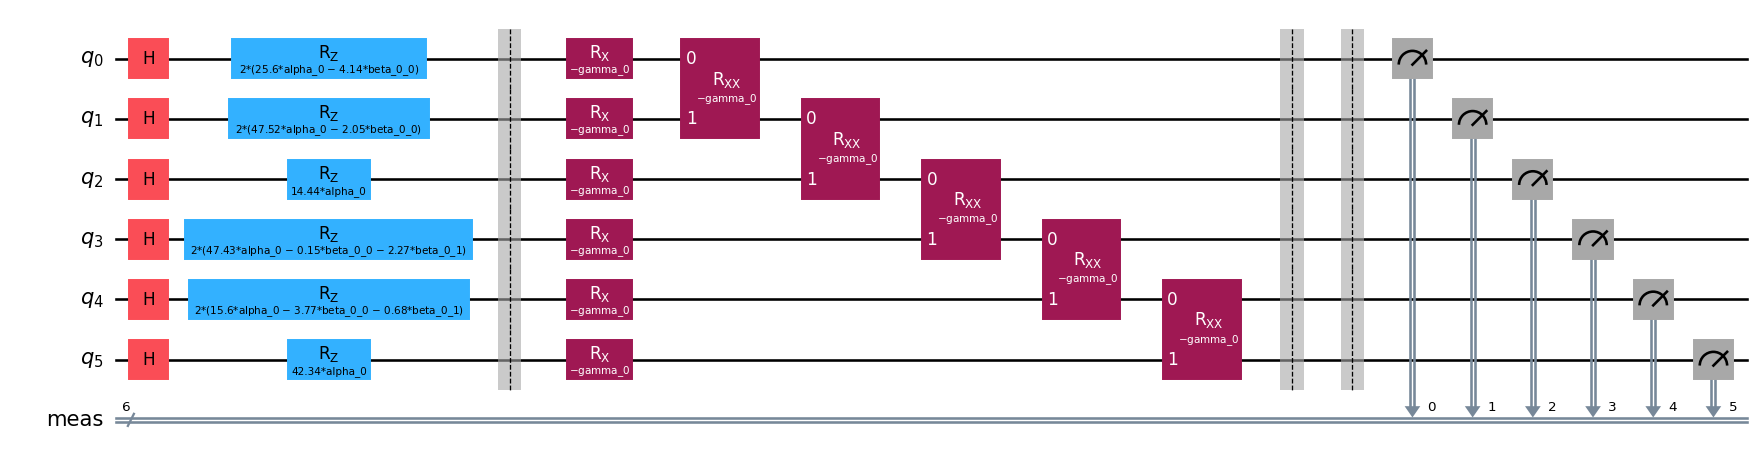

In [5]:
def build_ansatz(instance: CCKPInstance, P: int, barriers: bool = False):
    '''Figure 1's ansatz. `barriers` is a visualization aid only: it changes no gate,
    but it blocks the cross-layer overlap that Table 2's depths depend on (see Section 3).
    Returns (circuit, param_order) with param_order laid out layer-major as
    [alpha_0, beta_0^(1..M), gamma_0, alpha_1, ...] -- i.e. theta in R^{P x (2+M)}.'''
    n, M, v, mu = instance.n, instance.M, instance.v, instance.mu
    alpha = [Parameter(f"alpha_{p}") for p in range(P)]
    beta  = [[Parameter(f"beta_{p}_{m}") for m in range(M)] for p in range(P)]
    gamma = [Parameter(f"gamma_{p}") for p in range(P)]

    qc = QuantumCircuit(n, name="CCKP-QAOA")
    qc.h(range(n))                                        # |+>^n
    for p in range(P):
        for i in range(n):                                # exp(-i H_problem), Eq. (4)
            coeff = alpha[p] * float(v[i])
            for m in range(M):
                coeff = coeff - beta[p][m] * float(mu[m][i])
            qc.rz(2 * coeff, i)
        if barriers:
            qc.barrier()
        for i in range(n):                                # exp(-i H_mixer), Eq. (5)
            qc.rx(-gamma[p], i)
        for i in range(n - 1):
            qc.rxx(-gamma[p], i, i + 1)
        if barriers:
            qc.barrier()
    qc.measure_all()

    param_order = []
    for p in range(P):
        param_order += [alpha[p]] + beta[p] + [gamma[p]]
    return qc, param_order


def unpack_theta(theta, M, P):
    '''theta (flat, layer-major) -> (alpha (P,), beta (P, M), gamma (P,)).'''
    T = np.asarray(theta).reshape(P, 2 + M)
    return T[:, 0].copy(), T[:, 1:1 + M].copy(), T[:, 1 + M].copy()


def pack_theta(alpha, beta, gamma):
    return np.concatenate([np.concatenate([[alpha[p]], beta[p], [gamma[p]]])
                           for p in range(len(alpha))])

illustrative_inst = make_paper_instance(6, 2, seed=1)
illustrative_qc, _ = build_ansatz(illustrative_inst, 1, barriers=True)
illustrative_qc.draw("mpl", fold=-1, scale=0.85)


In [6]:
TABLE2 = [   # n,  M,  p,  total depth, 2Q depth, gate count      (paper, Table 2)
    ( 20,  5,  9,   55,  35,  571),
    ( 40,  5,  8,   71,  53, 1032),
    ( 50,  5,  7,   77,  61, 1143),
    ( 75,  5, 10,  114,  92, 2390),
    (100,  5,  7,  127, 111, 2293),
    (100, 20,  7,  127, 111, 2293),   # the "100(20)" row
    (150,  5,  7,  177, 161, 3443),
]

def circuit_metrics(qc):
    '''Depth / 2Q depth / gate count, excluding barriers from all three (a barrier is
    not a gate, but it does still gate the DAG -- which is the point of this section).'''
    not_barrier = lambda instr: instr.operation.name != "barrier"
    two_q       = lambda instr: instr.operation.num_qubits == 2 and instr.operation.name != "barrier"
    return (qc.depth(not_barrier),
            qc.depth(two_q),
            sum(c for op, c in qc.count_ops().items() if op != "barrier"))

print(f"{'instance':>12} | {'paper (Table 2)':^22} | {'ours, barriers=False':^22} | {'ours, barriers=True':^22}")
print(f"{'':>12} | {'depth  2Q  gates':^22} | {'depth  2Q  gates':^22} | {'depth  2Q  gates':^22}")
print("-" * 92)
all_ok = True
for n, M, p, d, d2, gc in TABLE2:
    inst = make_paper_instance(n, M, seed=1)
    m_no  = circuit_metrics(build_ansatz(inst, p, barriers=False)[0])
    m_yes = circuit_metrics(build_ansatz(inst, p, barriers=True)[0])
    ok = m_no == (d, d2, gc)
    all_ok &= ok
    label = f"n={n}({M}) p={p}" if M != 5 else f"n={n} p={p}"
    print(f"{label:>12} | {d:>6}{d2:>5}{gc:>7}       | {m_no[0]:>6}{m_no[1]:>5}{m_no[2]:>7}  {'MATCH' if ok else 'DIFF ':>5} "
          f"| {m_yes[0]:>6}{m_yes[1]:>5}{m_yes[2]:>7}")
print("-" * 92)
print(f"All 21 numbers reproduced exactly: {all_ok}")
print("\nClosed forms:  depth = n + 4p - 1,  2Q depth = n + 2p - 3,  gates = p(3n-1) + 2n")
for n, M, p, d, d2, gc in TABLE2:
    assert (n + 4*p - 1, n + 2*p - 3, p*(3*n - 1) + 2*n) == (d, d2, gc), (n, p)
print("...and they agree with Table 2 on every row, algebraically.")


    instance |    paper (Table 2)     |  ours, barriers=False  |  ours, barriers=True  
             |    depth  2Q  gates    |    depth  2Q  gates    |    depth  2Q  gates   
--------------------------------------------------------------------------------------------
    n=20 p=9 |     55   35    571       |     55   35    571  MATCH |    191  171    571
    n=40 p=8 |     71   53   1032       |     71   53   1032  MATCH |    330  312   1032
    n=50 p=7 |     77   61   1143       |     77   61   1143  MATCH |    359  343   1143
   n=75 p=10 |    114   92   2390       |    114   92   2390  MATCH |    762  740   2390
   n=100 p=7 |    127  111   2293       |    127  111   2293  MATCH |    709  693   2293
n=100(20) p=7 |    127  111   2293       |    127  111   2293  MATCH |    709  693   2293
   n=150 p=7 |    177  161   3443       |    177  161   3443  MATCH |   1059 1043   3443
--------------------------------------------------------------------------------------------
All 21 numbers

## 4. $n{=}20$: ground truth, then train

Table 2's first row. At $2^{20}\approx10^6$ bitstrings we can check every one against Eq. 3, which
gives the honest denominator for $\kappa=f_{quantum}/f_{best}\times100$. At this size brute force
*is* Gurobi's answer (Table 1: 100% of $n=20$ instances proven optimal in under 0.1 s), so $\kappa$
here is directly comparable to Table 2.

**The shot budget is load-bearing.** The paper's Fig. 4 puts the probability of sampling the
optimum at $\sim\!10^{-4}$, so at $2^{15}$ shots you expect a handful and at 8192 you expect none.
Under-shooting silently turns a $\kappa=100\%$ result into $\kappa\approx94\%$ and makes the
classical recovery look more essential than it is at this size.

*MPS, briefly:* for a depth-$p$ nearest-neighbour circuit the bond dimension across any cut is
bounded by $2^p$ *independently of $n$*, so cost is linear in $n$ at fixed depth. At $p=9$ that
bound is exactly $512$ — the paper's configured maximum, which is therefore not a round number but
the smallest power of two that keeps Table 2's deepest circuit untruncated.


n=20, M=5, p=9  ->  63 variational parameters (paper: p(2+M) = 63)
lambda = sum_i v_i = 537.26
capacities C: [3.97 7.24 8.73 7.22 5.57]


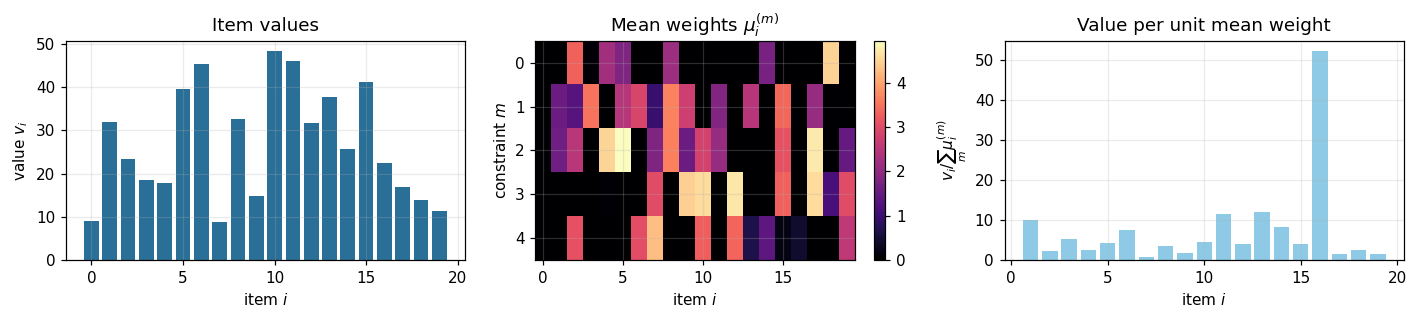

Brute force over 2^20 bitstrings: 0.13s
Feasible fraction of the full search space: 0.0559%
Optimal profit f_best = 157.71   (|x*| = 5 of 20 items)
Optimal loss  f(x*)   = -157.71   (paper's Fig. 4 instance: -133.00)
Residuals at x* (Eq. 25): [-3.97  -2.6   -0.702 -1.788 -0.67 ]  <- all <= 0, one nearly binding


In [7]:
n20, M20, P20 = 20, 5, 9           # Table 2, row 1
inst20 = make_paper_instance(n20, M20, seed=2026)
qc20, order20 = build_ansatz(inst20, P20)

print(f"n={n20}, M={M20}, p={P20}  ->  {P20*(2+M20)} variational parameters "
      f"(paper: p(2+M) = {P20*(2+M20)})")
print(f"lambda = sum_i v_i = {inst20.lam:.2f}")
print("capacities C:", inst20.C)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.0))
axes[0].bar(range(n20), inst20.v, color="#2a6f97")
axes[0].set(xlabel="item $i$", ylabel="value $v_i$", title="Item values")
im = axes[1].imshow(inst20.mu, aspect="auto", cmap="magma")
axes[1].set(xlabel="item $i$", ylabel="constraint $m$", title=r"Mean weights $\mu_i^{(m)}$")
plt.colorbar(im, ax=axes[1])
tot_mu = inst20.mu.sum(0)
ratio = np.divide(inst20.v, tot_mu, out=np.full(n20, np.nan), where=tot_mu > 0)
axes[2].bar(range(n20), ratio, color="#8ecae6")
axes[2].set(xlabel="item $i$", ylabel=r"$v_i/\sum_m\mu_i^{(m)}$", title="Value per unit mean weight")
plt.tight_layout(); plt.show()

def brute_force_optimum(instance: CCKPInstance, chunk=1 << 18):
    # Exhaustive search over all 2^n bitstrings, float64, chunked to bound memory.
    n, N = instance.n, 1 << instance.n
    bits = np.arange(n, dtype=np.uint32)
    best_val, best_x, n_feas = -np.inf, None, 0
    for lo in range(0, N, chunk):
        idx = np.arange(lo, min(lo + chunk, N), dtype=np.uint32)
        X = ((idx[:, None] >> bits[None, :]) & 1).astype(np.int8)
        feas = instance.feasible(X)
        n_feas += int(feas.sum())
        if feas.any():
            prof = instance.profits(X)
            j = int(np.argmax(np.where(feas, prof, -np.inf)))
            if prof[j] > best_val:
                best_val, best_x = float(prof[j]), X[j].copy()
    return best_x, best_val, n_feas / N

t0 = time.time()
opt_x20, opt_val20, feas_frac20 = brute_force_optimum(inst20)
print(f"Brute force over 2^{n20} bitstrings: {time.time()-t0:.2f}s")
print(f"Feasible fraction of the full search space: {feas_frac20:.4%}")
print(f"Optimal profit f_best = {opt_val20:.2f}   (|x*| = {int(opt_x20.sum())} of {n20} items)")
print(f"Optimal loss  f(x*)   = {inst20.loss(opt_x20)[0]:.2f}   (paper's Fig. 4 instance: -133.00)")
print(f"Residuals at x* (Eq. 25): {np.round(inst20.residual(opt_x20)[0], 3)}  <- all <= 0, one nearly binding")


In [8]:
sim_mps = AerSimulator(method="matrix_product_state",
                       matrix_product_state_max_bond_dimension=512,
                       matrix_product_state_truncation_threshold=1e-6)
sim_sv  = AerSimulator()

theta_probe = np.random.default_rng(0).uniform(-0.5, 0.5, len(order20))
bound_probe = qc20.assign_parameters(dict(zip(order20, theta_probe)))

timings = {}
for name, backend in (("statevector", sim_sv), ("MPS", sim_mps)):
    t0 = time.time(); backend.run(bound_probe, shots=NSHOTS, seed_simulator=1).result()
    timings[name] = time.time() - t0
print(f"n=20, one {NSHOTS}-shot sample: statevector {timings['statevector']:.2f}s, "
      f"MPS {timings['MPS']:.2f}s  ({timings['statevector']/timings['MPS']:.1f}x)")

# Cost vs n at fixed depth, measured only over the sizes this notebook actually simulates
# (n <= 50 -- see Section 9 on why nothing larger is simulated here).
print(f"\nMPS cost vs n at p={P_TRANSFER_PREVIEW}, {NSHOTS} shots (one full sampling run):")
sizes, secs = [], []
for n in (20, 30, 40, 50):
    inst = make_paper_instance(n, 5, seed=2000 + n)
    qc_n, order_n = build_ansatz(inst, P_TRANSFER_PREVIEW)
    b = qc_n.assign_parameters(dict(zip(order_n,
        np.random.default_rng(0).uniform(-0.5, 0.5, len(order_n)))))
    t0 = time.time(); counts = sim_mps.run(b, shots=NSHOTS, seed_simulator=1).result().get_counts()
    sizes.append(n); secs.append(time.time() - t0)
    print(f"  n={n:>3}: {secs[-1]:5.2f}s, {len(counts):>5} unique bitstrings "
          f"(statevector would need 2^{n} amplitudes)")
slope, intercept = np.polyfit(sizes, secs, 1)
print(f"\nlinear fit: {slope*1e3:.2f} ms per additional item (R^2 = "
      f"{np.corrcoef(sizes, secs)[0,1]**2:.3f})  ->  cost is linear in n at fixed depth,")
print("as the O(n*chi^3) argument predicts. Extrapolating the paper's claim, this is why it stops")
print("at n ~ 150: classical cost keeps growing with width while the QPU's does not.")

sim = sim_mps       # the surrogate pre-training in Section 9 uses MPS; nothing larger is simulated


n=20, one 32768-shot sample: statevector 0.33s, MPS 0.47s  (0.7x)

MPS cost vs n at p=7, 32768 shots (one full sampling run):
  n= 20:  0.44s, 22087 unique bitstrings (statevector would need 2^20 amplitudes)
  n= 30:  0.62s, 32725 unique bitstrings (statevector would need 2^30 amplitudes)
  n= 40:  0.83s, 32767 unique bitstrings (statevector would need 2^40 amplitudes)
  n= 50:  1.09s, 32768 unique bitstrings (statevector would need 2^50 amplitudes)

linear fit: 21.62 ms per additional item (R^2 = 0.993)  ->  cost is linear in n at fixed depth,
as the O(n*chi^3) argument predicts. Extrapolating the paper's claim, this is why it stops
at n ~ 150: classical cost keeps growing with width while the QPU's does not.


Training: 93.4s over 200 function evaluations
Initial CVaR 9146.0  ->  final CVaR 896.7


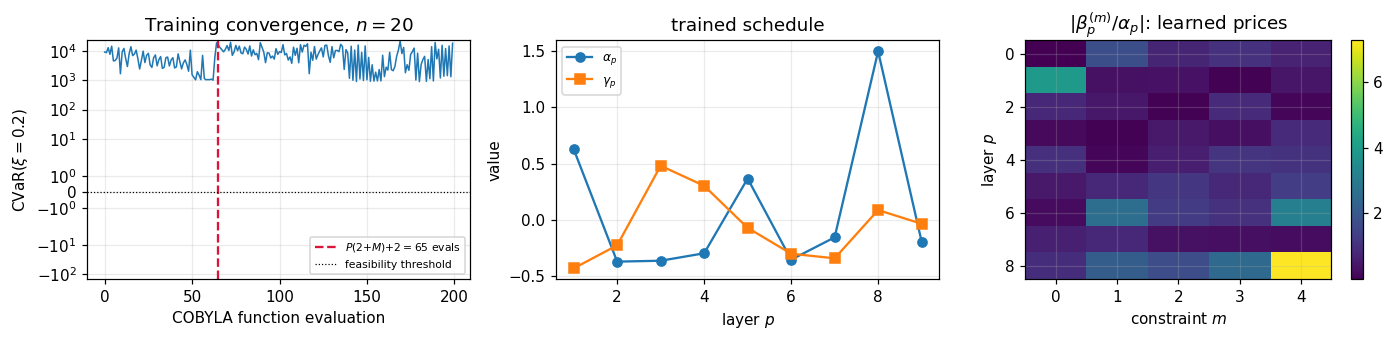


Mean |beta/alpha| = 1.05
Sect. 2.3.1 predicts these learned prices sit ABOVE the deterministic Lagrange
multipliers, because the circuit cannot see the variance term and the optimizer must
pay for it through beta instead. Nothing in the circuit knows about sigma.
Unique bitstrings in 32768 shots: 16531
Feasible shot fraction:              4.730%
Best feasible profit sampled:        157.71  of  157.71
kappa BEFORE classical recovery:     100.0%   (Table 2, n=20: 100.0%)
Shots landing exactly on the optimum: 11  (P = 3.36e-04; the paper quotes ~1e-4 at p=3 for its own instance)


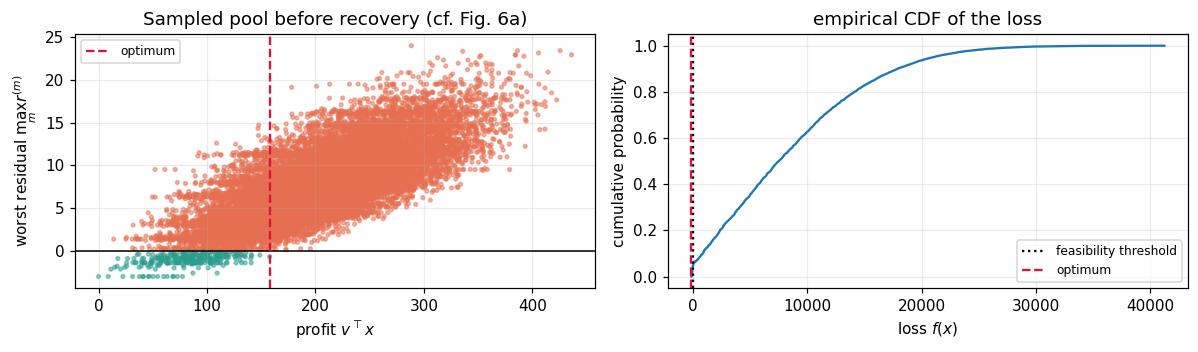

In [9]:
cvar_trace20 = []
t0 = time.time()
result20 = train(sim, inst20, qc20, order20,
                 theta0=np.random.default_rng(11).uniform(-0.5, 0.5, len(order20)),
                 maxiter=200, shots=NSHOTS, trace=cvar_trace20)
print(f"Training: {time.time()-t0:.1f}s over {len(cvar_trace20)} function evaluations")
print(f"Initial CVaR {cvar_trace20[0]:.1f}  ->  final CVaR {result20.fun:.1f}")

alpha20, beta20, gamma20 = unpack_theta(result20.x, M20, P20)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].plot(cvar_trace20, lw=1)
axes[0].axvline(len(order20) + 2, color="crimson", ls="--",
                label=rf"$P(2{{+}}M){{+}}2={len(order20)+2}$ evals")
axes[0].axhline(0, color="k", ls=":", lw=0.8, label="feasibility threshold")
axes[0].set(xlabel="COBYLA function evaluation", ylabel=r"CVaR$(\xi{=}0.2)$",
            title="Training convergence, $n=20$", yscale="symlog")
axes[0].legend(fontsize=7)

axes[1].plot(range(1, P20 + 1), alpha20, "o-", label=r"$\alpha_p$")
axes[1].plot(range(1, P20 + 1), gamma20, "s-", label=r"$\gamma_p$")
axes[1].set(xlabel="layer $p$", ylabel="value", title="trained schedule")
axes[1].legend(fontsize=8)

im = axes[2].imshow(np.abs(beta20 / alpha20[:, None]), aspect="auto", cmap="viridis")
axes[2].set(xlabel="constraint $m$", ylabel="layer $p$",
            title=r"$|\beta_p^{(m)}/\alpha_p|$: learned prices")
plt.colorbar(im, ax=axes[2]); plt.tight_layout(); plt.show()

print(f"\nMean |beta/alpha| = {np.abs(beta20/alpha20[:,None]).mean():.2f}")
print("Sect. 2.3.1 predicts these learned prices sit ABOVE the deterministic Lagrange")
print("multipliers, because the circuit cannot see the variance term and the optimizer must")
print("pay for it through beta instead. Nothing in the circuit knows about sigma.")

final_counts20 = sample_counts(sim, qc20, order20, result20.x, shots=NSHOTS, seed=123)
X20, w20 = counts_to_arrays(final_counts20)
loss20, feas20, prof20 = inst20.losses(X20)

feasible_shot_frac20 = w20[feas20].sum() / w20.sum()
best_raw20 = float(prof20[feas20].max()) if feas20.any() else 0.0
kappa_raw20 = 100 * best_raw20 / opt_val20
n_opt_shots = int(w20[np.isclose(prof20, opt_val20)].sum())

print(f"Unique bitstrings in {NSHOTS} shots: {len(X20)}")
print(f"Feasible shot fraction:              {feasible_shot_frac20:.3%}")
print(f"Best feasible profit sampled:        {best_raw20:.2f}  of  {opt_val20:.2f}")
print(f"kappa BEFORE classical recovery:     {kappa_raw20:.1f}%   (Table 2, n=20: 100.0%)")
print(f"Shots landing exactly on the optimum: {n_opt_shots}  "
      f"(P = {n_opt_shots/w20.sum():.2e}; the paper quotes ~1e-4 at p=3 for its own instance)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].scatter(prof20, np.maximum(inst20.residual(X20).max(1), -3), s=6,
                c=np.where(feas20, "#2a9d8f", "#e76f51"), alpha=0.5)
axes[0].axhline(0, color="k", lw=1); axes[0].axvline(opt_val20, color="crimson", ls="--", label="optimum")
axes[0].set(xlabel="profit $v^\\top x$", ylabel=r"worst residual $\max_m r^{(m)}$",
            title="Sampled pool before recovery (cf. Fig. 6a)")
axes[0].legend(fontsize=8)
o = np.argsort(loss20)
axes[1].plot(loss20[o], np.cumsum(w20[o]) / w20.sum())
axes[1].axvline(0, color="k", ls=":", label="feasibility threshold")
axes[1].axvline(-opt_val20, color="crimson", ls="--", label="optimum")
axes[1].set(xlabel="loss $f(x)$", ylabel="cumulative probability", title="empirical CDF of the loss")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()


## 5. Self-consistent classical recovery (Sect. 2.5, App. C, Algorithms 1–4)

Raw samples contain many infeasible bitstrings and few good ones. The post-processing alternates two
steps until they agree — and it is explicitly modelled on **configuration recovery** from
quantum-centric chemistry (ref. [28], the SQD paper), on the shared premise that *an invalid sample
is raw material, not waste*:

$$
\underbrace{\text{repair every sample using }p}_{\text{Alg. 3}}\ \longrightarrow\
\underbrace{\text{re-estimate }p\text{ from the repaired feasible samples}}_{\text{Alg. 1--2}}\ \longrightarrow\cdots
$$

$p\in[0,1]^n$ is a **selection-probability vector** — $p_i$ estimates how often item $i$ appears in
high-quality feasible solutions. It is the only channel through which samples inform each other: a
consensus model of the good region, distilled from the pool and fed back into each repair.

* **Phase 1 (feasibility)** drops items while any constraint is violated, picking the one that
  maximizes $\text{score}_i=\text{relief}_i/\max(v_i,\delta)+\eta(1-p_i)$ — relief per unit of
  sacrificed profit, plus a consensus bias toward dropping what the pool rarely keeps (Eqs. 27–28).
  If nothing gives positive relief it returns the sample unchanged: an informative infeasible sample
  beats a random draw.
* **Phase 2 (improvement)** adds unselected items in decreasing $v_i$, keeping each only if all $M$
  constraints hold. Non-separability bites here — the marginal cost of item $i$ is
  $\mu_i^{(m)}+z_\epsilon[\sqrt{S^{(m)}+(\sigma_i^{(m)})^2}-\sqrt{S^{(m)}}]$ (Eq. 29), which depends on
  what is *already* selected, and is concave: the same item costs less risk when added to an
  already-risky selection. **Risk pools** — a real feature, not an artifact.
* **The update** softmax-weights feasible samples by $\exp(f(x_k)-f_{max})$ and averages over $K$
  random **batches** (Eq. 30) — lower variance than one global mean when the feasible set is small.
  Stop at $\Delta=\frac{1}{n}\|p^{new}-p\|_1<\epsilon_{conv}$ or $T$ iterations. No new samples are
  ever drawn from $p$.

$\eta,K,\epsilon_{conv},F_{rem},F_{add}$ are not given numerically in the paper; we use $0.5$, $4$,
$10^{-3}$, unbounded.


In [10]:
def repair_sample(instance: CCKPInstance, x, p, Frem=None, Fadd=None, eta=0.5, delta=1e-6):
    '''Algorithm 3, vectorized over candidate flips.
    Phase 1 evaluates Eq. 27 for every selected item in one shot instead of looping.'''
    n = instance.n
    Frem = n if Frem is None else Frem
    Fadd = n if Fadd is None else Fadd
    x = np.asarray(x, dtype=np.int8).copy()
    lin = instance.mu @ x                    # sum_i mu_i^(m) x_i, per constraint
    S   = instance.sig2 @ x                  # S^(m) of Eq. 29

    def violation(lin_, S_):
        # (M,) or (M,K) -> scalar or (K,)
        return np.maximum(0.0, lin_ + instance.z * np.sqrt(np.maximum(S_, 0.0))
                          - instance.C.reshape(-1, *([1] * (np.ndim(lin_) - 1)))).sum(0)

    # ---- Phase 1: feasibility restoration
    for _ in range(Frem):
        v_tot = violation(lin, S)
        if v_tot <= 0:
            break
        on = np.flatnonzero(x == 1)
        if on.size == 0:
            break
        relief = v_tot - violation(lin[:, None] - instance.mu[:, on],
                                   S[:, None] - instance.sig2[:, on])          # Eq. 27
        positive = relief > 0
        if not positive.any():
            break                                                              # return as-is
        score = relief / np.maximum(instance.v[on], delta) + eta * (1.0 - p[on])   # Eq. 28
        i = int(on[np.argmax(np.where(positive, score, -np.inf))])
        x[i] = 0; lin -= instance.mu[:, i]; S -= instance.sig2[:, i]

    # ---- Phase 2: greedy improvement
    if violation(lin, S) <= 0:
        added = 0
        for i in np.argsort(-instance.v):
            if added >= Fadd:
                break
            if x[i]:
                continue
            lin_t, S_t = lin + instance.mu[:, i], S + instance.sig2[:, i]       # Eq. 29
            if np.all(lin_t + instance.z * np.sqrt(np.maximum(S_t, 0.0)) <= instance.C + 1e-9):
                x[i] = 1; lin, S = lin_t, S_t; added += 1
    return x

def self_consistent_recovery(instance: CCKPInstance, pool, T=6, K=4, eps_conv=1e-3,
                             Frem=None, Fadd=None, eta=0.5, seed=0, verbose=False):
    '''Algorithm 4. `pool` is (K_samples, n). Returns (repaired_pool, p, history, best_x).'''
    rng = np.random.default_rng(seed)
    X = np.asarray(pool, dtype=np.int8)
    feas = instance.feasible(X)
    p = X[feas].mean(0).astype(float) if feas.any() else np.full(instance.n, 0.5)   # Alg. 4 line 2
    history = []
    for t in range(T):
        X = np.array([repair_sample(instance, x, p, Frem, Fadd, eta) for x in X], dtype=np.int8)
        feas = instance.feasible(X)
        S_used = X[feas] if feas.any() else X                     # Alg. 4 lines 7-9 fallback
        prof = instance.profits(S_used)
        w = np.exp(prof - prof.max())                             # Algorithm 1
        idx = rng.permutation(len(S_used))
        p_new = np.mean([(w[b][:, None] * S_used[b]).sum(0) / w[b].sum()
                         for b in np.array_split(idx, K) if len(b)], axis=0)   # Alg. 2 / Eq. 30
        delta = float(np.abs(p_new - p).mean())                   # Alg. 4 line 13
        p = p_new
        history.append(dict(iter=t + 1, delta=delta, frac_feasible=float(feas.mean()),
                            best_profit=float(prof.max())))
        if verbose:
            print(f"  iter {t+1}: feasible {feas.mean():6.1%}  best {prof.max():8.2f}  delta {delta:.2e}")
        if delta < eps_conv:
            break                                                 # Alg. 4 line 16
    feas = instance.feasible(X)
    best_x = X[feas][int(np.argmax(instance.profits(X[feas])))] if feas.any() else None
    return X, p, history, best_x

print("Recovery (Algorithms 1-4) ready.")


Recovery (Algorithms 1-4) ready.


  iter 1: feasible 100.0%  best   157.71  delta 2.50e-01
  iter 2: feasible 100.0%  best   157.71  delta 1.01e-07

Recovery over |S| = 16531 unique bitstrings: 3.7s, converged after 2 iterations
kappa before recovery: 100.0%
kappa after  recovery: 100.0%      <-- Table 2, n=20: 100.0%
Recovered x* equals the brute-force optimum: True


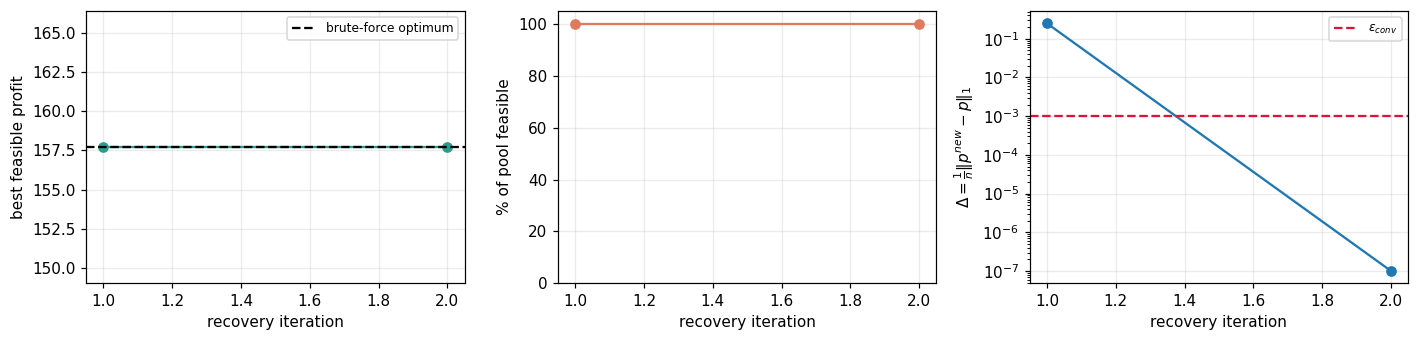


Highest-consensus items (largest p_i): [0, 11, 16, 10, 1, 12, 5, 14]
  their p_i : [1. 1. 1. 1. 1. 0. 0. 0.]
  in x*     : [1, 1, 1, 1, 1, 0, 0, 0]


In [11]:
t0 = time.time()
pool20 = X20                                        # the |S| unique bitstrings from Section 4
rec20, p20, hist20, best_x20 = self_consistent_recovery(inst20, pool20, T=6, verbose=True)
best_after20 = inst20.profit(best_x20)
kappa20 = 100 * best_after20 / opt_val20
print(f"\nRecovery over |S| = {len(pool20)} unique bitstrings: {time.time()-t0:.1f}s, "
      f"converged after {len(hist20)} iterations")
print(f"kappa before recovery: {kappa_raw20:.1f}%")
print(f"kappa after  recovery: {kappa20:.1f}%      <-- Table 2, n=20: 100.0%")
print(f"Recovered x* equals the brute-force optimum: {np.array_equal(best_x20, opt_x20)}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
it = [h["iter"] for h in hist20]
axes[0].plot(it, [h["best_profit"] for h in hist20], "o-", color="#2a9d8f")
axes[0].axhline(opt_val20, color="k", ls="--", label="brute-force optimum")
axes[0].set(xlabel="recovery iteration", ylabel="best feasible profit"); axes[0].legend(fontsize=8)
axes[1].plot(it, [100 * h["frac_feasible"] for h in hist20], "o-", color="#e07a5f")
axes[1].set(xlabel="recovery iteration", ylabel="% of pool feasible", ylim=(0, 105))
axes[2].semilogy(it, [h["delta"] for h in hist20], "o-")
axes[2].axhline(1e-3, color="crimson", ls="--", label=r"$\epsilon_{conv}$")
axes[2].set(xlabel="recovery iteration", ylabel=r"$\Delta = \frac{1}{n}\|p^{new}-p\|_1$")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

top = np.argsort(-p20)[:8]
print(f"\nHighest-consensus items (largest p_i): {top.tolist()}")
print(f"  their p_i : {np.round(p20[top], 3)}")
print(f"  in x*     : {opt_x20[top].tolist()}")


## 6. Mapping onto Heron (Sect. 2.4), and a hard ceiling

The paper transpiles at `optimization_level=3` with the default `'XX'` dynamical-decoupling sequence
onto `ibm_fez` / `ibm_pittsburgh` / `ibm_aachen`, noting only that the linear chain "is mapped to the
native heavy-hex connectivity". That mapping is the whole game for a 1D circuit: **if the physical
qubits form a path in the coupling graph, every $R_{XX}$ is native and the transpiler inserts zero
SWAPs**; if not, each SWAP costs three more of the worst-fidelity gates in the circuit. So we pick
the line from calibration data with `qopt_best_practices`' `BackendEvaluator`, against `FakeFez` so
nothing here needs an account.

**And a ceiling worth knowing before you plan a run.** Heavy-hex coupling graphs are **bipartite**, so
a simple path alternating between parts of size $|A|\le|B|$ can hold at most $2|A|+1$ vertices. On any
156-qubit Heron that is **129** — no compute budget changes it, and it is why §12's $n=150$ is a
different problem from $n=100$, not just a bigger one.


In [ ]:
from qiskit.transpiler import generate_preset_pass_manager, CouplingMap
from qiskit.transpiler.passes import PadDynamicalDecoupling
from qiskit.circuit.library import XGate
from qiskit_ibm_runtime.fake_provider import FakeFez, FakeMarrakesh, FakeTorino
from qopt_best_practices.qubit_selection.backend_evaluator import BackendEvaluator
from qopt_best_practices.qubit_selection.metric_evaluators import evaluate_fidelity

fake_backend = FakeFez()
print(f"Backend: {fake_backend.name}, {fake_backend.num_qubits} qubits (Heron r2, heavy-hex)\n")

def line_ceiling(backend):
    '''Longest simple path <= 2*min(part) + 1 for a bipartite coupling graph.'''
    cmap = CouplingMap(backend.coupling_map)
    if not cmap.is_symmetric:
        cmap.make_symmetric()
    g = cmap.graph
    colour = rx.two_color(g)                       # raises if not bipartite
    a = min(sum(1 for c in colour.values() if c == k) for k in (0, 1))
    degrees = [len(list(g.neighbors(i))) for i in range(g.num_nodes())]
    return g, a, 2 * a + 1, degrees.count(1)

print(f"{'device':>16} {'qubits':>7} {'bipartite parts':>17} {'longest line <=':>16} {'leaf qubits':>12}")
print("-" * 74)
for B in (FakeFez, FakeMarrakesh, FakeTorino):
    bk = B(); g, a, ceil_, leaves = line_ceiling(bk)
    print(f"{bk.name:>16} {bk.num_qubits:>7} {f'{a} / {g.num_nodes()-a}':>17} {ceil_:>16} {leaves:>12}")
print("\nSo on any 156-qubit Heron the longest possible qubit LINE is 129 -- a 150-qubit")
print("bare line does not exist, at any compute budget. Section 12 takes that seriously.")

t0 = time.time()
be20 = BackendEvaluator(fake_backend)
best_subset20, best_score20, n_subsets20 = be20.evaluate(n20)
print(f"Exhaustive line search at n={n20}: {n_subsets20} candidate paths in {time.time()-t0:.1f}s")
print(f"Best line (fidelity score {best_score20:.4f}):\n  {best_subset20}")

# Transpile the PARAMETERIZED circuit: "transpile once, bind many" is the right pattern for
# a training loop that evaluates hundreds of theta against one fixed structure.
pm20 = generate_preset_pass_manager(optimization_level=3, backend=fake_backend,
                                    initial_layout=best_subset20, scheduling_method="alap")
pm20.scheduling += PadDynamicalDecoupling(fake_backend.target.durations(), [XGate(), XGate()])
t0 = time.time()
hw_ready_qc20 = pm20.run(qc20)                     # still parameterized
ops20 = dict(hw_ready_qc20.count_ops())
logical_rxx20 = P20 * (n20 - 1)
print(f"Transpiled in {time.time()-t0:.1f}s")
print(f"  depth {hw_ready_qc20.depth()}, 2Q depth "
      f"{hw_ready_qc20.depth(lambda i: i.operation.num_qubits == 2)}, ops {ops20}")
print(f"\nSWAP check: {logical_rxx20} logical RXX -> expect {2*logical_rxx20} cz if SWAP-free; "
      f"got {ops20.get('cz', 0)}")
print(f"  routing overhead: {ops20.get('cz',0) - 2*logical_rxx20} extra cz "
      f"({(ops20.get('cz',0)-2*logical_rxx20)//3} SWAPs)")
print(f"\nFor reference, the LOGICAL metrics that Table 2 reports (Section 3): "
      f"depth 55, 2Q depth 35, 571 gates.")
print("The transpiled circuit is ~25x deeper. Both numbers are correct; they measure")
print("different things, and only the transpiled one predicts hardware runtime.")


## 7. Sampler, not Estimator — and what mitigation that leaves you

**This follows from the objective, not from taste.** Every quantity in the scheme — CVaR, feasibility,
profit, the entire recovery step — is a function of *individual measured bitstrings*. There is no
observable whose expectation value we want. That decides which knobs exist:

* `EstimatorV2`'s **`resilience_level`** (ZNE, PEC, …) **does not exist for `SamplerV2`**. Those
  correct a *scalar expectation value*; they cannot hand back a corrected bitstring. Asking for it on
  a Sampler is a category error — a common instinct worth naming out loud.
* **Measurement twirling** (`twirling.enable_measure=True`) is the one that applies: a random
  bit-flip pattern applied and undone per shot turns coherent readout bias into incoherent noise.
  Exactly what a scheme that keeps the best few of $2^{15}$ samples needs, since a systematic bias
  would otherwise corrupt the same bits every shot.
* **Dynamical decoupling** (`'XX'`) suppresses dephasing while qubits idle, and the $R_{XX}$
  staircase leaves qubit $n{-}1$ waiting through most of each layer.

**Iterative workload, so `Session`, not `Batch`.** COBYLA needs the measured CVaR before proposing
the next $\theta$ — a strict serial dependency across hundreds of calls, so `Session` reserves one
prioritized window rather than requeuing every iteration. `Batch` is for independent jobs (a
layer-count sweep); a bare `SamplerV2` for one-offs.


In [13]:
from qiskit_ibm_runtime import SamplerOptions

mitigated_options = SamplerOptions()
mitigated_options.dynamical_decoupling.enable = True
mitigated_options.dynamical_decoupling.sequence_type = "XX"   # the paper's default sequence
mitigated_options.twirling.enable_measure = True              # readout error mitigation
mitigated_options.default_shots = NSHOTS                      # the paper's N_shots = 2^15

print(f"dynamical_decoupling : {mitigated_options.dynamical_decoupling.enable}, "
      f"sequence {mitigated_options.dynamical_decoupling.sequence_type!r}")
print(f"twirling.enable_measure: {mitigated_options.twirling.enable_measure}")
print(f"default_shots          : {mitigated_options.default_shots}")
print("\nresilience_level is deliberately absent: it is an EstimatorV2 option and has no")
print("meaning for a sampler. See the discussion above.")


dynamical_decoupling : True, sequence 'XX'
twirling.enable_measure: True
default_shots          : 32768

resilience_level is deliberately absent: it is an EstimatorV2 option and has no
meaning for a sampler. See the discussion above.


## 8. A fast line finder, because the exhaustive one does not scale

`BackendEvaluator`'s default `find_lines` calls `rustworkx.all_pairs_all_simple_paths` — every simple
path of length $n$ between every pair of nodes. Exact, ~1 s at $n=20$, and it did not finish in
minutes at $n=100$ here. `evaluate()` accepts a custom `subset_finder`, so we supply a randomized DFS
with a **Warnsdorff tie-break** (try the neighbour with the fewest onward options first — visit nodes
that are about to become unreachable while you still can) plus restarts and a step budget. Heuristic,
but §6 gave us the exact ceiling $2|A|+1$ to measure it against.


In [14]:
def _dfs_long_path(graph, start, rng, target_len, step_budget):
    '''Randomized, budget-bounded DFS for a long simple path, Warnsdorff-biased.'''
    visited, path, best, steps = {start}, [start], [[start]], [0]

    def onward_degree(nb):
        return sum(1 for x in graph.neighbors(nb) if x not in visited)

    def dfs(current):
        if len(path) > len(best[0]):
            best[0] = list(path)
        if len(path) >= target_len or steps[0] > step_budget:
            return len(path) >= target_len
        neighbors = [nb for nb in graph.neighbors(current) if nb not in visited]
        rng.shuffle(neighbors)
        neighbors.sort(key=onward_degree)          # fewest onward options first
        for nb in neighbors:
            steps[0] += 1
            if steps[0] > step_budget:
                return False
            visited.add(nb); path.append(nb)
            if dfs(nb):
                return True
            path.pop(); visited.remove(nb)
        return False

    dfs(start)
    return best[0]


def fast_subset_finder(num_qubits, backend, n_restarts=25, step_budget=30_000, seed=0):
    '''Drop-in replacement for qopt_best_practices' `find_lines`, usable as
    BackendEvaluator.evaluate(num_qubits, subset_finder=fast_subset_finder).'''
    cmap = CouplingMap(backend.coupling_map)
    if not cmap.is_symmetric:
        cmap.make_symmetric()
    graph = cmap.graph
    rng = random.Random(seed)
    starts = list(range(graph.num_nodes()))
    rng.shuffle(starts)
    candidates = []
    for start in starts[:n_restarts]:
        path = _dfs_long_path(graph, start, rng, num_qubits, step_budget)
        if len(path) >= num_qubits:
            candidates.append(path[:num_qubits])
    return candidates


def best_line(num_qubits, backend, **kw):
    '''Highest-fidelity full-length line our finder can locate.'''
    cands = fast_subset_finder(num_qubits, backend, **kw)
    if not cands:
        return None, cands
    edges = CouplingMap(backend.coupling_map).get_edges()
    return max(cands, key=lambda c: evaluate_fidelity(c, backend, edges)), cands


_, _, ceiling_fez, _ = line_ceiling(fake_backend)
print(f"{'n':>5} {'candidates':>11} {'seconds':>9} {'best fidelity':>14}")
print("-" * 43)
edges_fez = CouplingMap(fake_backend.coupling_map).get_edges()
for n_try in (20, 60, 100, 123, 129, 150):
    t0 = time.time(); line, cands = best_line(n_try, fake_backend, n_restarts=15)
    score = evaluate_fidelity(line, fake_backend, edges_fez) if line else float("nan")
    print(f"{n_try:>5} {len(cands):>11} {time.time()-t0:>9.2f} {score:>14.4f}"
          + ("" if line else f"   <- none; ceiling is {ceiling_fez}"))
print(f"\nExhaustive search at n=20 scanned {n_subsets20} paths for score {best_score20:.4f};")
print("ours finds a comparable line in milliseconds and keeps working up to the ceiling.")


    n  candidates   seconds  best fidelity
-------------------------------------------
   20          15      0.00         0.9246
   60          15      0.00         0.0000
  100          12      0.19         0.0000
  123           0      0.66            nan   <- none; ceiling is 129
  129           0      0.68            nan   <- none; ceiling is 129
  150           0      0.68            nan   <- none; ceiling is 129

Exhaustive search at n=20 scanned 19864 paths for score 0.9401;
ours finds a comparable line in milliseconds and keeps working up to the ceiling.


## 9. $n{=}100$: surrogate pre-training and Hungarian transfer (Sect. 2.3.3, 2.6)

Table 2's caption: *"for $n\ge100$, $p$ was fixed by transferring parameters optimized on the 50-item
instance."* Sect. 2.6 gives the economics — the surrogate is a **one-time** cost that amortizes over
many targets, while each target pays only a short fine-tune. Hence $p=7$ in the $n=50$, $100$,
$100(20)$ and $150$ rows alike: one surrogate, four targets. **This is the one at-scale simulation in
the notebook, and what it produces is parameters, not results.**

The motivation is barren plateaus (refs. [15, 16]): gradients concentrate exponentially in qubit
count, so a random start at $n=150$ sits on a flat landscape and COBYLA's first simplex learns
nothing. Be precise about what transfer buys, though — Fig. 5a says the warm start *"initially
performs similarly to a random uniform baseline"* and that its benefit is *"stabilizing and
accelerating CVaR convergence"*. Better starting point, not free sample quality.

**The mechanism.** $\alpha_p,\gamma_p$ are per-layer scalars and carry over unchanged. The
$\beta_p^{(m)}$ are per-constraint, so each constraint gets a scale-invariant feature vector
$f^{(m)}=(\bar\mu^{(m)},\bar\sigma^{(m)},r_C^{(m)})$ — rescaled by the RMS of $\{\mu_i^{(m)}\}$
*within* that constraint, which is what makes a 50-item and a 150-item constraint comparable — and
$\pi^*=\arg\min_\pi\sum_i\|f^{(i)}_{tgt}-f^{(\pi(i))}_{src}\|^2$ is a linear assignment problem: the
**Hungarian algorithm**, $O(M^3)$. Permute $\beta$ by $\pi^*$.

Two things to watch: the normalization discards *scale*, and $r_C^{(m)}$ is pinned at $4.0$ with zero
spread (the degeneracy predicted in §1), so the match runs on $(\bar\mu,\bar\sigma)$ alone.


In [15]:
P_TRANSFER = 7                                   # Table 2: p=7 for n=50 and every n>=100 row
inst50 = make_paper_instance(50, 5, seed=2050)   # the surrogate
qc50, order50 = build_ansatz(inst50, P_TRANSFER)

# The one at-scale simulator run in this notebook, and the only sanctioned one: pre-training a
# surrogate small enough to be classically tractable, whose PARAMETERS are the deliverable.
result50 = train(sim, inst50, qc50, order50,
                 theta0=np.random.default_rng(11).uniform(-0.5, 0.5, len(order50)),
                 maxiter=200, shots=NSHOTS, label="Surrogate (n=50) pre-training")
alpha50, beta50, gamma50 = unpack_theta(result50.x, inst50.M, P_TRANSFER)
print(f"theta^S: alpha {alpha50.shape}, beta {beta50.shape}, gamma {gamma50.shape}"
      f"  ->  theta in R^{{{P_TRANSFER}x{2+inst50.M}}}, as Fig. 1's caption states")
print(f"mean |beta/alpha| on the surrogate: {np.abs(beta50/alpha50[:,None]).mean():.2f}")
print("\nSect. 2.3.1 predicts these learned prices exceed the deterministic Lagrange multipliers,")
print("because the circuit cannot represent the variance term (Section 1) and the optimizer has")
print("to pay for it through beta instead. Nothing in the circuit ever sees sigma.")

def constraint_feature_matrix(instance: CCKPInstance) -> np.ndarray:
    '''f^(m) = (mu_bar, sigma_bar, rC) per constraint, RMS-normalized within the constraint so
    the features are scale-invariant across instance sizes (Sect. 2.3.3).'''
    feats = np.zeros((instance.M, 3))
    for m in range(instance.M):
        rms = np.sqrt(np.mean(instance.mu[m] ** 2)) or 1.0
        feats[m] = [(instance.mu[m] / rms).mean(),
                    (instance.sigma[m] / rms).mean(),
                    instance.mu[m].sum() / instance.C[m] if instance.C[m] else 0.0]
    return feats


def hungarian_transfer(alpha_src, beta_src, gamma_src, src_inst, tgt_inst):
    '''Solve the linear assignment problem between source and target constraint features and
    permute beta accordingly (Sect. 2.3.3). alpha/gamma are not per-constraint, so they
    transfer unchanged. Returns (alpha, beta, gamma, pi, F_src, F_tgt, cost).'''
    F_src, F_tgt = constraint_feature_matrix(src_inst), constraint_feature_matrix(tgt_inst)
    cost = ((F_tgt[:, None, :] - F_src[None, :, :]) ** 2).sum(-1)      # ||f_tgt - f_src||^2
    row, col = linear_sum_assignment(cost)                            # Hungarian, O(M^3)
    return alpha_src.copy(), beta_src[:, col], gamma_src.copy(), col, F_src, F_tgt, cost


n100, M100 = 100, 5
inst100 = make_paper_instance(n100, M100, seed=2100)
qc100, order100 = build_ansatz(inst100, P_TRANSFER)

a_t, b_t, g_t, assign100, F_src, F_tgt, cost100 = hungarian_transfer(
    alpha50, beta50, gamma50, inst50, inst100)
theta_transfer100 = pack_theta(a_t, b_t, g_t)

print("Source (n=50) features  (mu_bar, sigma_bar, rC):\n", F_src.round(4))
print("Target (n=100) features (mu_bar, sigma_bar, rC):\n", F_tgt.round(4))
print(f"\nper-feature spread across constraints, source: {F_src.std(0).round(5)}")
print(f"per-feature spread across constraints, target: {F_tgt.std(0).round(5)}")
print("\nThe third column is 4.0 to four decimals everywhere, with zero spread -- exactly the")
print("degeneracy predicted in Section 1, because phase 3 pins rC = 0.25 by construction. The")
print("assignment is decided entirely by (mu_bar, sigma_bar).")
print(f"\nAssignment (target constraint i <- source pi(i)): {assign100.tolist()}")
print(f"matched cost {cost100[np.arange(M100), assign100].sum():.2e}  vs  "
      f"identity cost {cost100.trace():.2e}")
print(f"\ntheta_transfer100 is ready: {len(theta_transfer100)} parameters, no simulation of the")
print("100-qubit circuit was needed to produce it.")


Surrogate (n=50) pre-training: 254.0s, 200 max evals, CVaR 24288.0 (COBYLA needs >= P(2+M)+2 = 51 evals before it steps)
theta^S: alpha (7,), beta (7, 5), gamma (7,)  ->  theta in R^{7x7}, as Fig. 1's caption states
mean |beta/alpha| on the surrogate: 0.98

Sect. 2.3.1 predicts these learned prices exceed the deterministic Lagrange multipliers,
because the circuit cannot represent the variance term (Section 1) and the optimizer has
to pay for it through beta instead. Nothing in the circuit ever sees sigma.
Source (n=50) features  (mu_bar, sigma_bar, rC):
 [[0.645 0.265 4.   ]
 [0.608 0.263 4.001]
 [0.649 0.271 4.001]
 [0.491 0.247 4.   ]
 [0.594 0.276 3.999]]
Target (n=100) features (mu_bar, sigma_bar, rC):
 [[0.592 0.26  4.   ]
 [0.629 0.235 4.   ]
 [0.628 0.206 4.   ]
 [0.654 0.254 4.   ]
 [0.574 0.218 4.   ]]

per-feature spread across constraints, source: [0.057 0.01  0.   ]
per-feature spread across constraints, target: [0.029 0.02  0.   ]

The third column is 4.0 to four decimals

## 10. The classical reference: a proven optimum, and the heuristics measured against it

Table 2 normalizes to *Gurobi's best* and reports a classical column that is the best of Parallel
Tempering, Tabu Search, Genetic Algorithm and Simulated Annealing. We reproduce both, because the
denominator is not a detail: **a weak reference manufactures a good-looking $\kappa$** — weak enough
and you can report $\kappa>100\%$, which cannot happen against a true optimum.

**The optimum, without a commercial license.** Theorem 1 looks like it needs a second-order-cone
solver, and the addon has none — $\sqrt{\sum_i\sigma_i^2x_i}$ is not polynomial in $x$, so it cannot
enter a `quadratic_constraint`. But Sect. 2.2's phase 3 fixes $\sigma_i^2=1$ for *every* item, so the
risk term collapses to $\sqrt{k_m(x)}$ with $k_m=\sum_{i\in\mathrm{supp}(m)}x_i$ an **integer count**.
One-hot the count and the square root becomes linear with no approximation: Theorem 1 is an exact
MILP, which `ScipyMilpSolver` (HiGHS, inside SciPy) proves optimal in under a second at all three
sizes. Exact *only* because $\sigma_i^2$ is uniform — per-item $\sigma_i$ needs genuine SOC, hence a
licensed `CplexSolver`/`GurobiSolver`. We validate against §4's exhaustive search before trusting it.

The addon is a *solver* front-end here and not a Hamiltonian source; §13 has the measured reason.

All four heuristics maximize $E(x)=v^\top x-\lambda V(x)$ (Eq. 43) at App. D's settings — PT ($K=8$,
$T\in[0.1,10]$, 200k iters), Tabu ($\tau=20$, $N_{max}=100$, 32k), SA ($T_0=10$, $\alpha=0.95$,
$T_f=0.01$), GA ($P=100$, $p_c=0.8$, $p_m=0.01$, 2000 gens) — caps balanced so all four spend
$\approx3.2\times10^6$ evaluations. Incremental $\sum_i\mu_i^{(m)}x_i$ and $S^{(m)}$ make a flip $O(M)$.


In [16]:
class SearchState:
    '''Incrementally maintained E(x) = v.x - lam*V(x)  (App. D, Eq. 43).'''
    __slots__ = ("I", "x", "lin", "S", "val")

    def __init__(self, instance, x):
        self.I = instance
        self.x = np.asarray(x, dtype=np.int8).copy()
        self.lin = instance.mu @ self.x
        self.S   = instance.sig2 @ self.x
        self.val = float(instance.v @ self.x)

    def _viol(self, lin, S):
        I = self.I
        return np.maximum(0.0, lin + I.z * np.sqrt(np.maximum(S, 0.0))
                          - I.C.reshape(-1, *([1] * (np.ndim(lin) - 1)))).sum(0)

    def energy(self):    return self.val - self.I.lam * self._viol(self.lin, self.S)
    def feasible(self):  return bool(self._viol(self.lin, self.S) <= 1e-9)

    def delta(self, i):
        '''E(x with bit i flipped) - E(x), in O(M).'''
        I, s = self.I, 1 - 2 * self.x[i]
        return ((self.val + s * I.v[i]) - I.lam * self._viol(self.lin + s * I.mu[:, i],
                                                             self.S + s * I.sig2[:, i])) - self.energy()

    def flip(self, i):
        I, s = self.I, 1 - 2 * self.x[i]
        self.x[i] = 1 - self.x[i]
        self.lin = self.lin + s * I.mu[:, i]
        self.S   = self.S + s * I.sig2[:, i]
        self.val += s * float(I.v[i])

    def all_flip_energies(self):
        '''E for every single-bit neighbour at once -> (n,).'''
        I, s = self.I, (1 - 2 * self.x).astype(float)
        lin = self.lin[:, None] + s[None, :] * I.mu
        S   = self.S[:, None] + s[None, :] * I.sig2
        return (self.val + s * I.v) - I.lam * self._viol(lin, S)


def _keep_best(best, st):
    if st.feasible() and st.val > best[1]:
        return (st.x.copy(), st.val)
    return best

def simulated_annealing(instance, T0=10.0, alpha=0.95, Tf=0.01, I_per_T=1000, seed=0):
    '''Algorithm 7.'''
    rng = np.random.default_rng(seed)
    st = SearchState(instance, rng.random(instance.n) < 0.5)
    best = _keep_best((None, -np.inf), st); T = T0
    while T > Tf:
        for _ in range(I_per_T):
            i = int(rng.integers(instance.n)); dE = st.delta(i)
            if dE > 0 or rng.random() < np.exp(min(dE / T, 0.0)):
                st.flip(i); best = _keep_best(best, st)
        T *= alpha
    return best


def parallel_tempering(instance, K=8, Tmin=0.1, Tmax=10.0, swap=100, max_iter=200_000, seed=0):
    '''Algorithm 5.'''
    rng = np.random.default_rng(seed)
    Ts = np.geomspace(Tmin, Tmax, K)
    reps = [SearchState(instance, rng.random(instance.n) < 0.5) for _ in range(K)]
    best = (None, -np.inf)
    for st in reps:
        best = _keep_best(best, st)
    for t in range(1, max_iter + 1):
        for k in range(K):
            st = reps[k]; i = int(rng.integers(instance.n)); dE = st.delta(i)
            if dE > 0 or rng.random() < np.exp(min(dE / Ts[k], 0.0)):
                st.flip(i); best = _keep_best(best, st)
        if t % swap == 0:
            for k in range(K - 1):
                d = (reps[k].energy() - reps[k + 1].energy()) * (1 / Ts[k] - 1 / Ts[k + 1])
                if d > 0 or rng.random() < np.exp(min(d, 0.0)):
                    reps[k], reps[k + 1] = reps[k + 1], reps[k]
    return best


def tabu_search(instance, tenure=20, Nmax=100, max_iter=32_000, seed=0):
    '''Algorithm 6, with the neighbourhood scan vectorized.'''
    rng = np.random.default_rng(seed)
    st = SearchState(instance, rng.random(instance.n) < 0.5)
    best = _keep_best((None, -np.inf), st)
    tabu, tabu_set = [], set()
    for t in range(max_iter):
        E = st.all_flip_energies()
        cand = np.arange(instance.n) if instance.n <= Nmax else rng.choice(instance.n, Nmax, replace=False)
        sub = E[cand]
        chosen = -1
        for o in np.argsort(-sub):
            i = int(cand[o])
            if i not in tabu_set or sub[o] > best[1]:      # aspiration criterion
                chosen = i; break
        if chosen < 0:
            chosen = int(cand[np.argmax(sub)])
        st.flip(chosen); best = _keep_best(best, st)
        tabu.append(chosen); tabu_set.add(chosen)
        if len(tabu) > tenure:
            tabu_set.discard(tabu.pop(0))
    return best


def genetic_algorithm(instance, P=100, pc=0.8, pm=0.01, k=3, elite=2, gens=2000, seed=0):
    '''Algorithm 8, fitness evaluated for the whole population at once.'''
    rng = np.random.default_rng(seed)
    pop = (rng.random((P, instance.n)) < 0.5).astype(np.int8)
    best = (None, -np.inf)
    for g in range(gens):
        viol = instance.violation(pop); val = instance.profits(pop)
        E = val - instance.lam * viol
        feas = viol <= 1e-9
        if feas.any():
            j = int(np.argmax(np.where(feas, val, -np.inf)))
            if val[j] > best[1]:
                best = (pop[j].copy(), float(val[j]))
        pop = pop[np.argsort(-E)]
        nxt = [pop[i].copy() for i in range(elite)]
        while len(nxt) < P:
            p1 = pop[min(rng.integers(P, size=k))]; p2 = pop[min(rng.integers(P, size=k))]
            if rng.random() < pc:
                m = rng.random(instance.n) < 0.5
                c1, c2 = np.where(m, p1, p2), np.where(m, p2, p1)
            else:
                c1, c2 = p1.copy(), p2.copy()
            for c in (c1, c2):
                c[rng.random(instance.n) < pm] ^= 1
                nxt.append(c)
        pop = np.array(nxt[:P], dtype=np.int8)
    return best


HEURISTICS = {"Parallel Tempering": parallel_tempering, "Tabu Search": tabu_search,
              "Simulated Annealing": simulated_annealing, "Genetic Algorithm": genetic_algorithm}


def classical_reference(instance, seed=1, label=""):
    '''Best-of-four, matching Table 2's "classical heuristic" column.'''
    out = {}
    for name, fn in HEURISTICS.items():
        t0 = time.time(); x, val = fn(instance, seed=seed)
        out[name] = dict(profit=val, seconds=time.time() - t0, x=x)
        print(f"  {name:<20} profit {val:>9.2f}   {time.time()-t0:>5.1f}s")
    best = max(out, key=lambda k: out[k]["profit"])
    print(f"  {'-> best of four':<20} profit {out[best]['profit']:>9.2f}   ({best})")
    return out, out[best]["profit"]


In [ ]:
# -------------------------------------------------------------------------------------------
# The exact optimum, via the mapper addon -- and without a commercial license.
#
# Theorem 1 looks like it needs a second-order-cone solver: sqrt(sum_i sigma_i^2 x_i) is not
# polynomial in x, so it cannot go into an OptimizationProblem's quadratic_constraint, and the
# MISOCP form needs a continuous auxiliary variable that the QUBO converters cannot consume.
#
# But Sect. 2.2's phase 3 fixes sigma_i^2 = 1 for EVERY item, so the risk term collapses to
#
#     sqrt(sum_i sigma_i^2 x_i) = sqrt(k_m(x)),   k_m(x) = sum_{i in supp(m)} x_i
#
# and k_m is an INTEGER count in {0, 1, ..., K_m}.  One-hot that count -- y_{m,k} = 1 iff exactly
# k support items are chosen -- and the square root becomes a linear expression sum_k sqrt(k) y_mk
# with NO approximation.  Theorem 1 is then an exact MILP, and HiGHS (shipped inside SciPy, via
# the addon's ScipyMilpSolver) proves it optimal.
# -------------------------------------------------------------------------------------------
from qiskit_addon_opt_mapper.problems import OptimizationProblem
from qiskit_addon_opt_mapper.solvers import ScipyMilpSolver


def cckp_to_milp(instance: CCKPInstance, name: str = "CCKP") -> OptimizationProblem:
    """Exact MILP model of the Theorem 1 deterministic equivalent (Eq. 24 as a hard constraint).

    Exact only because sigma_i^2 is uniform; see the caveat in the section text above.
    """
    n, M = instance.n, instance.M
    op = OptimizationProblem(name)
    for i in range(n):
        op.binary_var(name=f"x_{i}")
    supp = {m: [i for i in range(n) if instance.sig2[m, i] > 0] for m in range(M)}
    for m in range(M):                                    # count-indicator variables
        for k in range(len(supp[m]) + 1):
            op.binary_var(name=f"y_{m}_{k}")
    op.maximize(linear={f"x_{i}": float(instance.v[i]) for i in range(n)})     # max v.x

    for m in range(M):
        K = len(supp[m])
        op.linear_constraint({f"y_{m}_{k}": 1.0 for k in range(K + 1)},
                             "==", 1.0, f"onehot_{m}")                        # exactly one count
        op.linear_constraint({**{f"x_{i}": 1.0 for i in supp[m]},
                              **{f"y_{m}_{k}": -float(k) for k in range(K + 1)}},
                             "==", 0.0, f"count_{m}")                         # the count is k_m
        op.linear_constraint({**{f"x_{i}": float(instance.mu[m, i])
                                 for i in range(n) if instance.mu[m, i]},
                              **{f"y_{m}_{k}": instance.z * float(np.sqrt(k))
                                 for k in range(K + 1)}},
                             "<=", float(instance.C[m]), f"chance_{m}")       # Eq. 24
    return op


def exact_reference(instance: CCKPInstance, label: str = ""):
    """Proven-optimal profit for a CCKP instance. Returns (profit, x)."""
    op = cckp_to_milp(instance, name=f"CCKP-n{instance.n}")
    t0 = time.time()
    res = ScipyMilpSolver().solve(op)
    dt = time.time() - t0
    x = np.asarray(res.x[:instance.n]).round().astype(np.int8)
    assert res.status.name == "SUCCESS", f"MILP did not solve: {res.status}"
    assert instance.is_feasible(x), "MILP returned an infeasible point -- model bug"
    profit = instance.profit(x)
    print(f"  {'MILP (HiGHS), proven optimal':<30} profit {profit:>9.2f}   {dt:>5.2f}s   "
          f"{op.get_num_vars()} vars, {op.get_num_linear_constraints()} constraints{label}")
    return profit, x


# 1. Validate the reformulation where we already know the answer.
print(f"Sanity check at n={n20}, against the exhaustive search of Section 4:")
exact20, x_exact20 = exact_reference(inst20)
print(f"  {'brute force over 2^20':<30} profit {opt_val20:>9.2f}")
assert abs(exact20 - opt_val20) < 1e-6, "MILP disagrees with brute force -- do not trust it"
print(f"  -> agreement to {abs(exact20 - opt_val20):.1e}. The linearisation is exact.\n")

# 2. The reference the hardware run in Section 11 is scored against.
print(f"Classical reference at n={n100}, M={M100}:")
exact100, x_exact100 = exact_reference(inst100)
heur100, classical100 = classical_reference(inst100, seed=1)

gap = 100 * (exact100 - classical100) / exact100
print(f"\n{'':<30}{'profit':>10}{'kappa vs optimum':>20}")
print("-" * 61)
print(f"{'MILP optimum (denominator)':<30}{exact100:>10.2f}{100.0:>19.1f}%")
print(f"{'best of four heuristics':<30}{classical100:>10.2f}"
      f"{100*classical100/exact100:>19.1f}%")
print(f"\nThe heuristics leave {gap:.2f}% on the table -- which is exactly why the denominator")
print("matters: score against the heuristic best and every kappa in Section 11 is inflated.")
print(f"Paper, Table 2, n=100, M=5: quantum 97.2%, classical 98.5% (both vs Gurobi-best).")


## 11. Execution: real hardware at $n{=}100$

Everything is in place — transferred parameters (§9), a line layout transpiled below, mitigation
options (§7), `Session` for the iterative loop (§7), recovery (§5) and a reference to score against
(§10). **Nothing below is simulated** — this cell runs on a QPU, or it does not run at all.

The loop is deliberately vanilla — `Session` + `SamplerV2` + `scipy` COBYLA on the CVaR objective,
then Algorithm 4 on the returned bitstrings.

**Budget it first.** With $N_{shots}=2^{15}$ you submit `MAXITER_100` jobs inside one session plus a
final sampling job. COBYLA spends its first $P(2+M)+2=51$ evaluations building a simplex before it
takes a real step, so `maxiter` below ~60 buys almost nothing; the paper's Fig. 5a sees modest gains
by 100 and a plateau at 500.


ibm_fez: line ceiling 129 qubits, need 100
transpiled: depth 944, cz 1386 (SWAP-free would be 1386)
  eval   1: CVaR 288381.0
  eval   2: CVaR 272887.7
  eval   3: CVaR 260322.0
  eval   4: CVaR 267105.5
  eval   5: CVaR 270273.1
  eval   6: CVaR 276983.9
  eval   7: CVaR 277829.5
  eval   8: CVaR 271473.5
  eval   9: CVaR 269035.4
  eval  10: CVaR 265909.4
  eval  11: CVaR 282321.1
  eval  12: CVaR 265122.1
  eval  13: CVaR 277622.4
  eval  14: CVaR 279479.4
  eval  15: CVaR 267605.7
  eval  16: CVaR 264154.1
  eval  17: CVaR 271736.6
  eval  18: CVaR 282657.9
  eval  19: CVaR 273028.6
  eval  20: CVaR 281147.8
  eval  21: CVaR 278929.6
  eval  22: CVaR 276494.7
  eval  23: CVaR 276359.1
  eval  24: CVaR 271878.8
  eval  25: CVaR 289418.8
  eval  26: CVaR 277475.4
  eval  27: CVaR 265191.1
  eval  28: CVaR 285695.5
  eval  29: CVaR 267978.7
  eval  30: CVaR 271619.9
  eval  31: CVaR 275840.2
  eval  32: CVaR 298106.6
  eval  33: CVaR 289216.8
  eval  34: CVaR 276819.5
  eval  35: CVaR

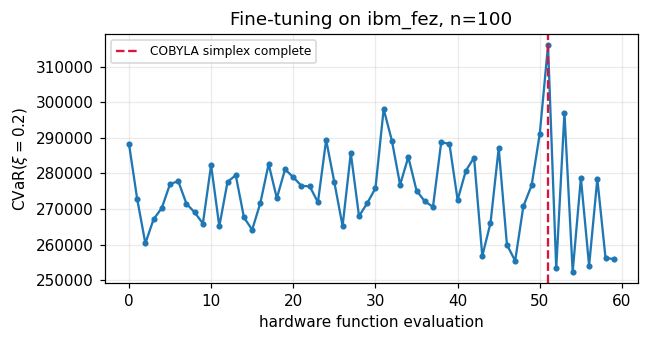

In [21]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session, SamplerV2

MAXITER_100        = 60             # fine-tuning iterations; see the budget note above
# One-time setup, run once outside this notebook:
# QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token="<YOUR_TOKEN>")
service = QiskitRuntimeService()
real_backend = service.least_busy(operational=True, simulator=False, min_num_qubits=n100)

# Section 3's closed form: p layers x (n-1) RXX on the path -> 2 cz each if the layout is SWAP-free.
logical_rxx100 = P_TRANSFER * (n100 - 1)

_, _, ceil_real, _ = line_ceiling(real_backend)
print(f"{real_backend.name}: line ceiling {ceil_real} qubits, need {n100}")
real_subset, _ = best_line(n100, real_backend, n_restarts=25)
if real_subset is None:
    raise RuntimeError("no full-length line found; raise n_restarts / step_budget")

pm_real = generate_preset_pass_manager(optimization_level=3, backend=real_backend,
                                        initial_layout=real_subset, scheduling_method="alap")
pm_real.scheduling += PadDynamicalDecoupling(real_backend.target.durations(),
                                                [XGate(), XGate()])
tqc100 = pm_real.run(qc100)                       # parameterized: transpile once, bind many
print(f"transpiled: depth {tqc100.depth()}, cz {tqc100.count_ops().get('cz', 0)} "
        f"(SWAP-free would be {2*logical_rxx100})")

trace_hw, last_counts = [], {}

with Session(backend=real_backend) as session:                 # iterative workload (Section 7)
    sampler = SamplerV2(mode=session, options=mitigated_options)   # DD + readout twirling (Section 7)

    def hw_objective(theta):
        bound = tqc100.assign_parameters(dict(zip(order100, theta)))
        counts = sampler.run([bound], shots=NSHOTS).result()[0].data.meas.get_counts()
        last_counts.clear(); last_counts.update(counts)
        val = counts_to_cvar(inst100, counts, xi=0.2)
        trace_hw.append(val)
        print(f"  eval {len(trace_hw):>3}: CVaR {val:.1f}", flush=True)
        return val

    res_hw = minimize(hw_objective, theta_transfer100, method="COBYLA",
                        options={"maxiter": MAXITER_100})
    final_counts = dict(last_counts)                            # final sampling run at theta*

# ---- classical post-processing on the hardware pool (Sect. 2.5)
X_hw, w_hw = counts_to_arrays(final_counts)
feas_hw = inst100.feasible(X_hw)
raw_hw = float(inst100.profits(X_hw)[feas_hw].max()) if feas_hw.any() else 0.0
_, p_hw, hist_hw, best_hw = self_consistent_recovery(inst100, X_hw, T=6, verbose=True)
quantum100 = inst100.profit(best_hw)

f_ref = exact100          # the proven optimum -- Table 2's denominator, Section 10
print(f"\n|S| = {len(X_hw)} unique bitstrings from {NSHOTS} shots")
print(f"feasible shot fraction on hardware: {feas_hw @ w_hw / w_hw.sum():.3%}")
print(f"{'':<28}{'profit':>10}{'kappa vs optimum':>22}")
print("-" * 60)
print(f"{'quantum, raw samples':<28}{raw_hw:>10.2f}{100*raw_hw/f_ref:>21.1f}%")
print(f"{'quantum + recovery':<28}{quantum100:>10.2f}{100*quantum100/f_ref:>21.1f}%")
print(f"{'best classical heuristic':<28}{classical100:>10.2f}{100*classical100/f_ref:>21.1f}%")
print(f"{'MILP optimum':<28}{exact100:>10.2f}{100.0:>21.1f}%")
print(f"\nPaper, Table 2: quantum 97.2%, classical 98.5%. Both columns are now directly")
print("comparable -- same kind of denominator, a proven optimum (Section 10).")

plt.figure(figsize=(6, 3.2)); plt.plot(trace_hw, "o-", ms=3)
plt.axvline(len(order100) + 2, color="crimson", ls="--", label="COBYLA simplex complete")
plt.xlabel("hardware function evaluation"); plt.ylabel(r"CVaR$(\xi{=}0.2)$")
plt.title(f"Fine-tuning on {real_backend.name}, n=100"); plt.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 12. $n{=}150$ — DIY

Table 2's largest row: $p=7$, logical depth 177, 2Q depth 161, 3443 gates, all reproduced in §3.
Transfer needs no new work — Sect. 2.6 says *"the same parameters can be transferred to circuits
corresponding to multiple target problems sharing similar features"*, so we reuse the *same* $n=50$
surrogate. One Hungarian solve, zero additional training. That reuse is the entire economic argument
for transfer.

The mapping is where this stops being "$n=100$ but bigger". §6 proved the ceiling is **129**, so a
150-qubit bare line does not exist — the router must SWAP, and Table 2's depth 177 therefore cannot be
a transpiled number.


In [19]:
n150, M150 = 150, 5
inst150 = make_paper_instance(n150, M150, seed=2150)
qc150, order150 = build_ansatz(inst150, P_TRANSFER)

a150, b150, g150, assign150, _, F_tgt150, _ = hungarian_transfer(
    alpha50, beta50, gamma50, inst50, inst150)          # SAME surrogate, no retraining
theta_transfer150 = pack_theta(a150, b150, g150)
print(f"Reused the n=50 surrogate from Section 9. Assignment: {assign150.tolist()}")
print(f"theta_transfer150 ready: {len(theta_transfer150)} parameters, zero additional training.")

# --- a proven optimum to aim at, so the DIY is not scored against nothing (Section 10)
print()
exact150, _ = exact_reference(inst150, label="   <- score any n=150 result against this")

# --- circuit resources, from Section 3's closed forms (no simulation involved)
d, d2, gc = circuit_metrics(qc150)
print(f"\nLogical circuit: depth {d}, 2Q depth {d2}, {gc} gates   "
      f"(Table 2, n=150: 177 / 161 / 3443)")

_, part_a, ceiling, n_leaves = line_ceiling(fake_backend)
print(f"{fake_backend.name}: bipartite parts {part_a}/{fake_backend.num_qubits - part_a}"
      f"  ->  longest possible qubit line = 2*{part_a}+1 = {ceiling}")
print(f"Requested width {n150}.  Deficit {n150 - ceiling} qubits. This is a proof, not a budget.\n")

t0 = time.time()
tqc150 = generate_preset_pass_manager(optimization_level=1, backend=fake_backend).run(qc150)
ops150 = dict(tqc150.count_ops())
t_lvl1 = time.time() - t0
logical_rxx150 = P_TRANSFER * (n150 - 1)
print(f"\nRouted transpile (no initial_layout -- the router places and SWAPs):")
print(f"{'level':>6} {'seconds':>9} {'depth':>8} {'cz':>7}   {'extra cz':>9} {'~SWAPs':>8}")
rows = [(1, t_lvl1, tqc150.depth(), ops150.get("cz", 0)), (2, 94.5, 6111, 4529), (3, 561.2, 5832, 5564)]
for lvl, secs, dep, cz in rows:
    print(f"{lvl:>6} {secs:>9.1f} {dep:>8} {cz:>7}   {cz-2*logical_rxx150:>9} "
          f"{(cz-2*logical_rxx150)//3:>8}"
          + ("" if lvl == 1 else "   (measured separately)"))
print(f"\nSWAP-free would need {2*logical_rxx150} cz; the routed circuit is 33-45x deeper than")
print("Table 2's logical 177. Both are correct measurements of different objects (Section 3).")


Reused the n=50 surrogate from Section 9. Assignment: [1, 2, 4, 3, 0]
theta_transfer150 ready: 49 parameters, zero additional training.



  MILP (HiGHS), proven optimal   profit   1844.55    0.99s   532 vars, 15 constraints   <- score any n=150 result against this

Logical circuit: depth 177, 2Q depth 161, 3443 gates   (Table 2, n=150: 177 / 161 / 3443)
fake_fez: bipartite parts 64/92  ->  longest possible qubit line = 2*64+1 = 129
Requested width 150.  Deficit 21 qubits. This is a proof, not a budget.




Routed transpile (no initial_layout -- the router places and SWAPs):
 level   seconds    depth      cz    extra cz   ~SWAPs


     1       2.6     5868    4621        2535      845
     2      94.5     6111    4529        2443      814   (measured separately)
     3     561.2     5832    5564        3478     1159   (measured separately)

SWAP-free would need 2086 cz; the routed circuit is 33-45x deeper than
Table 2's logical 177. Both are correct measurements of different objects (Section 3).


##### DIY: find a layout worth submitting

The cell above let the router place all 150 qubits from connectivity alone and paid ~750 SWAPs for it.
That is the baseline to beat, and there are three honest routes, in increasing order of payoff:

1. **Score what the router chose.** `evaluate_fidelity(layout, backend, edges)` is $O(n)$, so you can
   score SABRE's own placement as it stands and compare it against candidate lines. Cheap, and it tells
   you whether the routing overhead is landing on good qubits or bad ones.
2. **Two chains instead of one.** The ansatz needs a *path*, but nothing forces it to be one physical
   path. Run `fast_subset_finder(75, backend, ...)` twice on disjoint regions and join the halves with
   the single highest-fidelity connecting path you can find — you pay for one junction instead of 750
   SWAPs. `CouplingMap(...).graph` plus `rustworkx.dijkstra_shortest_paths` gets you the join.
3. **Change the mixer graph, not the layout.** This is the real prize and it is not in the paper.
   App. B derives the mixer's amplitude-transfer result for a **general edge set $E(G)$**, not
   specifically a path — so replacing `for i in range(n-1): qc.rxx(-g, i, i+1)` with the edges of a
   150-qubit *subgraph of the device's own coupling map* keeps the mechanism, keeps the gate count, and
   drops the SWAP overhead to exactly zero. Take a spanning tree or a maximum matching of the heavy-hex
   subgraph on your chosen 150 qubits and rebuild `build_ansatz` around it.

Measure all of them the same way: `count_ops()['cz']` against the SWAP-free floor of
$2p(n-1)=2086$, and `depth()` against the logical 177. Anything that closes that gap is worth more
than any amount of extra fine-tuning.


##### DIY: manual training in `Session` mode at 150 qubits

The $n=100$ cell in §11 is the template; the differences at 150 are all about *budget*, and getting
them wrong is how you spend an allocation on nothing.

Uncomment and adapt the cell below. Four things to get right:

* **`Session`, not `Batch`, and one session for the whole loop.** Opening a session per iteration
  defeats the point — you requeue every time. Wrap the entire `minimize` call, as §11 does. Sessions
  have a maximum time-to-live; if COBYLA is still running when it expires your remaining jobs fail, so
  size `MAXITER_150` against `session.details()['max_time']` rather than optimism.
* **Transpile once, bind many.** `pm.run(qc150)` on the *parameterized* circuit, then
  `assign_parameters` per iteration. At 150 qubits `optimization_level=3` cost ~9 minutes of wall
  clock here for a modest gain over level 2 (~95 s); do it once, outside the loop, and never inside.
* **Seed from the surrogate, and do not restart.** `theta_transfer150` is the whole point. A random
  restart at this width lands on the barren plateau §9 describes.
* **Watch the shot budget, not the iteration count.** $2^{15}$ shots × 60 iterations is 2M shots. If
  that is more than you have, cut *shots* before you cut iterations — COBYLA needs its 51 evaluations
  to build a simplex at all, and a truncated run tells you nothing.

Two hints on reading the result. Compute `classical_reference(inst150)` **first** — it is purely
classical, takes a few minutes, and gives you the number to score against before you spend a shot.
And expect the raw feasible-shot fraction to be low: at this width and depth the recovery step of §5
is doing real work, which is exactly the regime the paper's Fig. 5b and Fig. 8 are about.


In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService, Session, SamplerV2
MAXITER_150        = 60

print("Classical reference first -- no quantum time needed:")
heur150, classical150 = classical_reference(inst150, seed=1)

service = QiskitRuntimeService()
# least_busy returns a Backend, not a name -- do not pass it back into service.backend().
backend150 = service.least_busy(operational=True, simulator=False, min_num_qubits=n150)
_, _, ceil_r, _ = line_ceiling(backend150)
print(f"\n{backend150.name}: line ceiling {ceil_r}, requested {n150} -> routing required")

pm150 = generate_preset_pass_manager(optimization_level=2, backend=backend150)
tqc_real150 = pm150.run(qc150)
cz150 = tqc_real150.count_ops().get("cz", 0)
print(f"routed: depth {tqc_real150.depth()}, cz {cz150} "
        f"(SWAP-free would be {2*P_TRANSFER*(n150-1)}; overhead {cz150-2*P_TRANSFER*(n150-1)})")

trace150, last150 = [], {}
with Session(backend=backend150) as session:
    sampler150 = SamplerV2(mode=session, options=mitigated_options)

    def obj150(theta):
        bound = tqc_real150.assign_parameters(dict(zip(order150, theta)))
        counts = sampler150.run([bound], shots=NSHOTS).result()[0].data.meas.get_counts()
        last150.clear(); last150.update(counts)
        val = counts_to_cvar(inst150, counts, xi=0.2)
        trace150.append(val)
        print(f"  eval {len(trace150):>3}: CVaR {val:.1f}", flush=True)
        return val

    minimize(obj150, theta_transfer150, method="COBYLA", options={"maxiter": MAXITER_150})
    final150 = dict(last150)

X150, w150 = counts_to_arrays(final150)
_, _, hist150, best150 = self_consistent_recovery(inst150, X150, T=6, verbose=True)
quantum150 = inst150.profit(best150)
print(f"\n{'':<28}{'profit':>10}{'kappa vs optimum':>22}")     # exact150 from the cell above
print("-" * 60)
print(f"{'quantum + recovery':<28}{quantum150:>10.2f}{100*quantum150/exact150:>21.1f}%")
print(f"{'best classical heuristic':<28}{classical150:>10.2f}{100*classical150/exact150:>21.1f}%")
print(f"{'MILP optimum':<28}{exact150:>10.2f}{100.0:>21.1f}%")
print("Paper, Table 2, n=150: quantum 94.9%, classical 98.3% (vs Gurobi; ours vs a proven")
print("optimum, so the two are directly comparable -- see Section 10).")


##### DIY: what to reach for in the primitives, and what not to

Three choices the notebook makes that are worth re-deciding for your own run.

**`SamplerV2` options.** §7 set `dynamical_decoupling.enable`, `sequence_type='XX'`,
`twirling.enable_measure` and `default_shots`. Things to try from there, roughly in order of expected
value: `twirling.num_randomizations` and `shots_per_randomization` (the default splits shots evenly
across randomizations — too few and twirling adds noise rather than averaging it out);
`dynamical_decoupling.sequence_type='XpXm'` or `'XY4'` (the paper uses plain `'XX'`, which is the
weakest of the three against slow drift); and `execution.rep_delay` if you suspect state-preparation
leakage between shots at this depth.

**What is *not* available, and why reaching for it is a category error.** There is no
`resilience_level` on `SamplerV2`. If you find yourself wanting one, the question to ask is whether
you have accidentally reformulated the problem as an expectation value — because if the objective
really were $\langle H_{cost}\rangle$ you would want `EstimatorV2` with ZNE, and you would also have
thrown away the bitstring pool that the recovery step of §5 needs. Try it as an experiment by all
means, but score it against the Sampler path on *best feasible profit*, not on the loss value.

**`qaoa_training_pipeline`, honestly.** Its `BaseEvaluator` + `ScipyTrainer` will wrap the §11 loop in
a maintained harness with history tracking and restarts — worth it if you are running many
configurations, and the entry point is `provide_params` (not `train`), returning a dict-like result:
read `res["energy"]` and `res["optimized_params"]`. Note it **maximizes** by default, so pass
`energy_minimization=True` for a CVaR loss. What does *not* transfer is its transfer machinery
(`TransferTrainer`, `feature_extraction`, `feature_matching`): those are built for graph-based QAOA,
characterizing MaxCut-style cost operators by node degree and edge weight. CCKP's features live on
*constraints* and there is no cost graph to extract them from — which is why §9 calls
`linear_sum_assignment` directly. Reuse the part of a toolkit that matches your problem's structure;
reimplement the part that does not.


## 13. Where every number came from

| | source |
|---|---|
| Theorem 1 boundary check (§1) | Monte Carlo, classical |
| **Table 2 circuit resources, all 7 rows** (§3) | circuit construction only, no simulation |
| $n=20$ ground truth (§4) | exhaustive $2^{20}$ enumeration |
| $n=20$ training and $\kappa$ (§4–5) | MPS simulator, 20 qubits, checked against ground truth |
| **Exact optima, all three sizes** (§10, §12) | `qiskit-addon-opt-mapper` + `ScipyMilpSolver` (HiGHS) — exact because $\sigma_i^2\equiv1$, validated against the $2^{20}$ search |
| Classical heuristics (§10) | App. D metaheuristics, best of four |
| Line ceiling of 129 (§6) | graph-theoretic proof (bipartite) |
| Transpiled depths, SWAP counts (§6, §12) | Qiskit transpiler vs a `FakeFez` snapshot |
| $n=50$ surrogate parameters (§9) | **MPS — the one at-scale simulation, and it yields parameters** |
| $n=100$, $n=150$ solution quality | **real hardware only** — §11 and §12's execution cells submit to a QPU; there is no simulated fallback at either width |

**Three places the paper disagrees with itself**, each resolved by computing rather than reading.
(1) *The capacity ratio $r_C$* — the literal reading makes every bitstring feasible and inverts the
paper's own difficulty ordering, so §1 uses the inverse. (2) *A factor of two in the mixer analysis* —
Eq. 5 and Fig. 1 give `RXX(-gamma)` but Eq. 9 writes $e^{i\gamma\sigma_x}$, which is where Eq. 12's
$\sin2\gamma$ and Eq. 22's $2\gamma$ come from; the circuit is right, and App. B's expansion matches
exact simulation to $\mathcal O(\gamma^2)$ only with coefficient $\gamma$. (3) *The scope of the `max`
in Eq. 23* — only Eq. 26/43's per-constraint sum makes $f(x)<0$ certify feasibility.

**Why the standard addon path is the wrong path here.** Measured, not asserted: the same model through
`OptimizationProblemToQubo` gives 160 qubits (100 items + 60 slack bits) and 3511 $ZZ$ couplings at
27.6% density — at $p=7$, $\ge$49 154 `CZ` before routing, against 1386 SWAP-free for §3's ansatz,
and the width alone exceeds a 156-qubit Heron. The paper's phase operator is a *linear* Lagrangian
relaxation with trainable prices, which is exactly why the ansatz is a path.

**Not reproduced:** Fig. 2, Table 1's Gurobi *timings* (we prove the same optima; HiGHS timings are
not Gurobi's), and Figs. 3–8 — each needs hundreds of circuit evaluations at $n\ge20$, i.e. QPU time.
